# 4a · Per-cell training

Stage 4a of the chain. **One cell is one training example**, and its label is its cell line's
response — so every cell of a line carries the same number. `4b` trains the same model on the same
folds with one *cell line* as the example; the pair is named for that difference and for nothing
else.

**Position** `1_data` → `2_drug_selection` → `3_representations` → **`4a`** → `4b` → `5_evaluation`

| | |
|---|---|
| **in** | `hvg5000/…_with_targets_auc_cc.h5ad` — `obsm['X_pca']`, `obsm['X_scGPT']`, `Y_ctrp`, `M_ctrp`, `obs['split_ctrp']` |
| | `outputs/panel/panel.csv` — the drug panel, **read here, never restated** |
| **out** | `panel_oof_predictions.csv` — one row per (arm, drug, cell line), stamped with its fold |
| | `panel_per_drug_correlation.csv` — one row per (arm, drug); the seed axis is kept, not collapsed |
| | `panel_within_line_spread.csv` — the within-line spread `4b` stage 1 is anchored on |
| | `panel_ridge_baseline.csv`, `panel_leaderboard.csv` |
| | `runs/percell/*.npy` — the per-cell predictions themselves (untracked, large) |

## The architecture

One trunk over the cell's representation, one linear head per panel drug:

```
input(512) → Dropout(0.1) → [Linear → LayerNorm → GELU → Dropout(0.5)] × (128, 64) → Linear(64, K)
```

`AdamW`, no weight decay, head biases initialised at the fitting-fold per-drug mean. The loss is
masked — `sum(err · M) / sum(M)` — so a cell contributes only to the drugs its line was screened
against.

**Why one trunk and K heads rather than K models.** What a cell's representation has to encode is
largely shared across drugs; separate models would re-learn it K times from ~150 labels each.

**Why the head bias is initialised.** `auc_cc` sits near 0.9, `nn.Linear` starts near 0. Without it
the first epochs are spent climbing to the drug means rather than learning the differences between
cell lines — and early stopping then selects a checkpoint from that climb.

## What is swept

| axis | levels | why it is an axis |
|---|---|---|
| representation | `X_pca`, `X_scGPT` | the project's central comparison |
| loss | `mse`, `mae` | review item 9A — MAE is less pulled by the thinly-populated extremes |
| density weight `α` | 0, 0.5, 1 | weight is `kde^(−α)`, so `α=0` is exactly weight 1 — a level, not a switch |
| model seed | 42, 43, 44 | every margin is judged against the seed band, and one seed has no band |

2 × 2 × 3 × 3 = 36 arms × 5 folds = **180 fits**.

**Held fixed across all of them:** the fold partition, the trunk, the optimizer, the epoch cap, and
the **PCA seed** — which is deliberately *not* the model seed. Were it, three model seeds would
refit the representation three times, and the band would measure pipeline variability instead of
model variability. It must also equal `4b`'s, or the two notebooks mean different things by
"seed 43".

**The rule that governs the run.** Target and architecture never move together, or a difference
cannot be attributed to either. Here the architecture is fixed and the loss axis moves.

## Registered before the run

Density weighting should **raise** rank correlation and **worsen** MSE: shrinkage toward the mean is
what a squared-error optimum requires, and the weighting buys ranking by giving that up. Both moving
the same way means the mechanism did not do what it is for.

Its *magnitude* is genuinely unknown. The expectation that used to stand here rested on the `auc`
1.1 winsorization (retired 11.08.2026) and on a skew measured on the void 8-drug panel. Saying so is
a better pre-registration than a prediction resting on a retired step.

In [1]:
import glob
import inspect
import json
from dataclasses import replace
import os
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir())
NB_DIR = ROOT / 'notebooks'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)  # runs/ lives at the project root

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import RidgeCV

from scripts.layout import PipelinePaths
from scripts.model.OncoMLP import OncoMLP
from scripts.training.cv import (
    fold_pca_projections_for,
    grouped_folds,
    inner_holdout,
    line_level_predictions,
    oof_predictions,
)
from scripts.training.density_weighting import (
    DEFAULT_ALPHA,
    DEFAULT_CAP,
    line_level,
)
from scripts.training.train_multitask import DEFAULT_HIDDEN_DIMS, cv_evaluate, train_rep
from scripts.training.training_utils import TrainConfig

# Section A -- the panel run. Section B -- the PCA-vs-scGPT matrix, folded in from 2_training on
# 12.08.2026. Separate output trees because they answer different questions and their tables are
# not interchangeable. Each variable below is the directory it is named for; nothing appends to
# them at the call sites.
OUT = NB_DIR / 'outputs' / 'panel'
OUT_MATRIX = NB_DIR / 'outputs' / 'archive' / 'training_545_mean_pv'
#
# History of OUT_MATRIX, in one place and in the past tense -- it was fixed three times and each
# fix left its own comment standing, so this cell carried three accounts of which two had become
# false. In 2_training section B used `OUT = NB_DIR / 'outputs'` and every call site appended
# 'archive' / 'training_545_mean_pv'. The fold-in set it to NB_DIR / 'outputs' / 'matrix', which
# with that suffix resolved to outputs/matrix/legacy/... -- a directory that never existed -- so
# the CV guard never saw the committed folds and silently recomputed while reporting that it had
# loaded them. f6cbef4 restored NB_DIR / 'outputs', which fixed the guard but left the summary
# glob empty, since that one place globbed the variable itself. Consolidating the suffix into the
# variable and dropping it from all ten call sites fixed the guard and the glob for the same
# reason instead of separately. Behaviour never changed: the writes have always landed here.
#
# Section B writes inside legacy/, which outputs/README defines as what a standard run cannot
# recreate -- and section B re-runs at R4. The tension is real and was DECIDED rather than
# resolved: it stays in legacy/ (Selin, 12.08.2026), and outputs/README is not reworded to
# accommodate it. Consolidating the suffix into the variable is what makes revisiting that
# a one-line change here instead of an eleven-site one.
OUT.mkdir(parents=True, exist_ok=True)
OUT_MATRIX.mkdir(parents=True, exist_ok=True)

SCORE, VARIANT = 'auc_cc', 'hvg5000'
REPS = ['X_pca', 'X_scGPT']
# THE PANEL IS READ, NOT RESTATED (Selin, 13.08.2026). Until today this was a literal holding the
# void 8-drug panel: methotrexate, dasatinib, paclitaxel, vincristine, afatinib, topotecan,
# tanespimycin, selumetinib. Only THREE of those are in the rebuilt panel. Five were excluded from it
# by the criterion this project retracted, and eight of the eleven Selin selected on published
# evidence were absent. docs/TODO.md R4 says "4a_percell_training.ipynb on the rebuilt panel" -- but
# nothing made the notebook obey it, so R4 would have trained on the void set, finished normally, and
# produced entirely plausible numbers for the wrong drugs.
#
# Read directly rather than through dreval_normalize.load_panel(), which does the same job: that
# module imports drevalpy at module level, and the training notebook should not need the benchmarking
# library installed in order to know which drugs it is training on.
PANEL_CSV = OUT / 'panel.csv'
if not PANEL_CSV.exists():
    raise FileNotFoundError(
        f'{PANEL_CSV} not found; it is written by 2_drug_selection.ipynb. There is deliberately no '
        f'fallback list -- proceeding quietly with a stale panel is the defect this replaces.')
_panel = pd.read_csv(PANEL_CSV)
if 'drug_key' not in _panel.columns:
    raise ValueError(
        f"{PANEL_CSV} has no 'drug_key' column. That is the CTRPv2 spelling the response data is "
        f"keyed by (e.g. 'platin'), as opposed to 'drug', the FDA list's name (e.g. 'Cisplatin').")
PANEL = _panel['drug_key'].tolist()
print(f'panel: {len(PANEL)} drugs from {PANEL_CSV.name} -> {PANEL}')
N_SPLITS, SEED = 5, 42
# THREE SEEDS (Selin, 13.08.2026). The single-seed run of 13.08 could not settle the loss
# comparison: item 9A scores an arm on `order` with the other three quantities as non-inferiority
# guards, each margin defaulting to that quantity's OWN seed band -- and one seed has no band. It
# also left the PCA-over-scGPT reversal resting on a single draw against a documented +-0.04 of seed
# variation. 42 is the original; 43 and 44 are its successors and are arbitrary, as any seed is.
SEEDS = (42, 43, 44)
# PCA_SEED IS FIXED AND IS **NOT** THE MODEL SEED (13.08.2026). It must equal 4b's PCA_SEED, or the
# two notebooks mean different things by "seed 43" and stage 1's seed-matched comparison comes apart:
# it claims the architecture is the only thing differing between its two columns, which is false if
# 4a's seed 43 was trained on a PCA fitted with seed 43 while 4b's was fitted with seed 42.
# Until today `oof_predictions` passed the model seed to the PCA, so three model seeds refitted the
# representation three times -- varying the input as well as the initialisation, and making the seed
# band measure pipeline variability instead of model variability.
PCA_SEED = 42
# The density-weighting levels swept in section A. {0.0, 0.5, 1.0} is audit 09's decision
# (density_weighting.py docstring; docs/steps/03). alpha=0 is not a special case: the weight is
# kde**(-alpha), so it is exactly 1 everywhere. Lives with the other run constants rather than
# beside the loop, so the banner below can state what is actually swept.
ALPHAS = (0.0, 0.5, 1.0)
# DIE LOSS-ACHSE (13.08.2026, Selin). Item 9A verlangt **MSE / MAE x alpha in {0, 0.5, 1}**, und
# alle Arme konkurrieren um EINEN Gewinner. Bis heute sweepte 4a nur alpha, mit loss='mse' aus
# TrainConfig -- die sechs Arme waren also 2 Repraesentationen x 3 alpha, nicht 2 Losses x 3 alpha.
# Die MAE-Achse wurde nie gefahren, obwohl `_make_loss_fn` sie seit 12.08 unterstuetzt.
#
# MAE ist weniger von den duenn besetzten Extremen gezogen -- dieselbe Achse, auf der auch die
# Density-Gewichtung wirkt. Die beiden sind deshalb NICHT unabhaengig, und das Gitter wird als
# Gitter gelesen, nicht als zwei getrennte eindimensionale Sweeps.
LOSSES = ('mse', 'mae')

# --- section B knobs (from 2_training) ---------------------------------------------
# ⚠️ SECTION B IS OFF BY DEFAULT (Selin, 13.08.2026). It is the archived K=545 PCA-vs-scGPT matrix,
# whose conclusions are already superseded and whose outputs go to outputs/archive/ -- and it trains
# on ALL 534 drugs, where section A trains on the 11-drug panel. Running it on every iteration of A
# meant 28 extra fits on a 534-head model to answer a question A is not asking.
#
# Set True when section B's own numbers are wanted. Section A does not read anything B produces.
RUN_SECTION_B = False
VARIANTS = ['hvg5000', 'all_genes']
TASKS = {'all_drugs': None, 'single_paclitaxel': ['paclitaxel']}
# LEFT False, deliberately, and it is NOT the same case as RECOMPUTE_CV below (13.08.2026, Gate 2).
# Its cache is `runs/`, which is gitignored and currently empty -- `find_run` returns None and the
# cell falls through to training. So it can only ever reuse runs produced by the code that is in the
# tree, never a committed artifact from a retired target. That is the whole difference: cv_folds.csv
# is a VOID file checked into the repository; runs/ is a scratch directory. Reusing the second is the
# behaviour the flag is for -- it stops R4 retraining 8 arms if the notebook is re-run after a crash.
# ⚠️ True seit 13.08.2026. `runs/` ist jetzt ein Symlink auf das Haupt-Checkout, und dort liegen
# 39 alte Laufverzeichnisse aus Mai-Juli -- auf zurueckgezogenen Targets, void Panels, altem Code.
# `find_run` nimmt den NEUESTEN Treffer, und die alten Meta-Daten passen auf die MATRIX-Kriterien
# (hvg5000/all_genes x X_pca/X_scGPT x all_drugs/subset). Mit False haette §B sie geladen und als
# Ergebnis dieses Laufs berichtet. Die frueher hier stehende Begruendung -- "runs/ ist leer, also
# trainiert die Zelle ohnehin" -- galt nur, solange runs/ leer war, und das ist jetzt vorbei.
RETRAIN_MATRIX = True    # nie einen gespeicherten Lauf laden; §B trainiert immer selbst
# True since 13.08.2026 (Selin, Gate 2): "void cache is worse than the cost".
# Was False, which loads OUT_MATRIX/cv_folds.csv when present -- and that file IS committed. It holds
# CV results computed at K=545 on the RETIRED mean_pv target, so R4 would have loaded numbers void on
# two independent grounds (target withdrawn 11.08, panel rebuilt 12.08) and printed "Loaded CV from
# ... (set RECOMPUTE_CV=True to rerun)", which reads as reassurance. Cost, accepted: §B recomputes
# 4 CV configurations at R4.
#
# ⚠️ It also means R4 WRITES a fresh cv_folds.csv into outputs/archive/, a directory whose README
# defines it as "what a standard run cannot recreate". That tension is pre-existing and was DECIDED
# rather than resolved (see OUT_MATRIX above, 12.08.2026); this flag makes it active rather than
# theoretical, and it is worth revisiting at R6 rather than here.
RECOMPUTE_CV = True
MIN_VAR_STD = 0.05       # 'real response variance' threshold for correlation
N_CV_SPLITS = N_SPLITS   # section B's own name for it; same partition as section A
MATRIX = [{'variant': v, 'rep': r, 'task': t, 'drugs': d}
          for v in VARIANTS for r in REPS for t, d in TASKS.items()]

# no_decay_bias_and_norm defaults to True, so it is not passed here. It replaced
# exclude_output_from_decay=True on 12.08.2026: that flag exempted the whole output Linear, its
# weight matrix included, while still decaying the LayerNorm parameters -- neither the convention
# nor what the docs described (docs/steps/03, "The uncentred target ... every training path").
#
# epochs=50 for BOTH sections (Selin, 12.08.2026), decided when section B was folded in.
# Section A had run at 25 and section B at 50. One config was preferred to two, at the higher
# cap. Note this reverts A's 50 -> 25 reduction, which was made on 36 recorded runs where the
# best epoch was median 6, max 11 and early stopping (patience 10) never reached 25 -- so
# TrainConfig's own default of 25 and its comment now differ from what this notebook uses.
config = TrainConfig(epochs=50, seed=SEED)

print('trunk        :', DEFAULT_HIDDEN_DIMS)
print('weight decay :', f'{config.weight_decay:g} on weight matrices; biases and LayerNorm exempt')
print('weighting    :', f'alpha swept over {list(ALPHAS)}, cap={DEFAULT_CAP} (no winsorization)'
      ' (alpha is an arm of the 9A comparison; cap is the default in density_weighting.py)')
print('epochs       :', config.epochs, '(sections A and B share one config)')

panel: 11 drugs from panel.csv -> ['doxorubicin', 'platin', 'etoposide', 'paclitaxel', 'gemcitabine', 'imatinib', 'erlotinib', 'sorafenib', 'dasatinib', 'crizotinib', 'afatinib']
trunk        : {'X_pca': (128, 64), 'X_scGPT': (128, 64)}
weight decay : 0 on weight matrices; biases and LayerNorm exempt
weighting    : alpha swept over [0.0, 0.5, 1.0], cap=3.0 (no winsorization) (alpha is an arm of the 9A comparison; cap is the default in density_weighting.py)
epochs       : 50 (sections A and B share one config)


### Why `weight_decay = 0.0` — the measurement, not the assertion

| | |
|---|---|
| **out** | three weight-matrix L2 norms: AdamW with decay, AdamW without, Adam with decay |

`Adam` → `AdamW` (Loshchilov & Hutter, ICLR 2019) changes what `weight_decay` *means*. Under `Adam`
the penalty enters the gradient and is then divided by the adaptive per-parameter step, so it is
rescaled; under `AdamW` it is applied to the parameters directly. At the same nominal value the two
do very different things.

**Why this cell exists rather than a sentence.** The inherited `1e-3` did not survive the optimizer
change with its effect intact, and the claim "it was doing nothing" is checkable. The cell prints
the three norms so it can be checked instead of believed.

⚠️ Whether this model *needs* weight decay is open. 0.0 is justified narrowly — no sourced value
exists for either optimizer, dropout is already substantial — not by "the model is not
regularization-limited", which rested on an ablation that is itself void.

> Gated off by default: this justifies the configuration, it is not on the training path.

In [2]:
RUN_WD_CHECK = False      # flip to True to reproduce the three norms below

if not RUN_WD_CHECK:
    print('RUN_WD_CHECK is False -- skipping the weight-decay justification (see the markdown above).')
else:
    from scripts.training.training_utils import _decay_param_groups

    def _weight_l2(model):
        """L2 norm over WEIGHT MATRICES only -- the tensors decay actually acts on.

        Biases and LayerNorm parameters are excluded by _decay_param_groups and would dilute the
        comparison if summed in, since they are identical across the three arms by construction.
        """
        with torch.no_grad():
            return float(torch.sqrt(sum((p ** 2).sum()
                                        for n, p in model.named_parameters() if p.ndim > 1)))

    def _norm_after(opt_cls, wd, *, steps=200, seed=SEED):
        """Train the REAL OncoMLP on synthetic input and report its weight norm.

        Synthetic input is deliberate and sufficient: how an optimizer applies weight decay is a
        property of the optimizer and the parameter grouping, not of the data. The architecture and
        the grouping are the real ones -- that is what the comparison is about.

        THE SETTINGS ARE PART OF THE RESULT and are fixed here so the numbers are reproducible:
        input_dim 64, hidden dims DEFAULT_HIDDEN_DIMS['X_pca'], output_dim len(PANEL), lr 1e-3,
        200 full-batch steps on 256 synthetic rows, seed SEED. Change any of them and the absolute
        norms move; the RATIO between the arms is the finding, not the norms themselves.
        """
        torch.manual_seed(seed)
        model = OncoMLP(input_dim=64, hidden_dims=DEFAULT_HIDDEN_DIMS['X_pca'],
                        dropout_rate=0.5, input_dropout=0.1, norm='layer',
                        output_dim=len(PANEL))
        opt = opt_cls(_decay_param_groups(model, wd), lr=1e-3)
        g = torch.Generator().manual_seed(seed)
        x = torch.randn(256, 64, generator=g)
        y = torch.randn(256, len(PANEL), generator=g)
        for _ in range(steps):
            opt.zero_grad()
            torch.nn.functional.mse_loss(model(x), y).backward()
            opt.step()
        return _weight_l2(model)

    arms = [('Adam  wd=1e-3', torch.optim.Adam,  1e-3),
            ('AdamW wd=1e-3', torch.optim.AdamW, 1e-3),
            ('AdamW wd=0   ', torch.optim.AdamW, 0.0)]
    got = {name: _norm_after(cls, wd) for name, cls, wd in arms}
    for name, v in got.items():
        print(f'  {name}  weight-matrix L2 = {v:.3f}')

    # ⚠️ These supersede the 8.971 / 8.975 / 5.597 recorded on 12.08.2026 in docs/TODO.md. Those came
    # from a scratch script that was never committed and no longer exists, so they cannot be
    # re-derived by anyone -- the exact failure item 12's closure describes. The conclusion is
    # unchanged and slightly stronger; only the absolute numbers differ, because the lost script's
    # settings differed from the ones fixed above. THIS CELL IS NOW THE SOURCE.
    aw1, aw0 = got['AdamW wd=1e-3'], got['AdamW wd=0   ']
    print(f'\n  AdamW 1e-3 vs AdamW 0 : {abs(aw1 - aw0) / aw0 * 100:.2f}% apart '
          f'-- indistinguishable, which is why weight_decay is 0.0')
    print(f'  Adam 1e-3 vs AdamW 0  : {abs(got["Adam  wd=1e-3"] - aw0) / aw0 * 100:.1f}% apart '
          f'-- the same nominal value under the old optimizer')


RUN_WD_CHECK is False -- skipping the weight-decay justification (see the markdown above).


## 1 · Load only what the model consumes

| | |
|---|---|
| **in** | the targets h5ad, opened **backed** |
| **out** | a lightweight `AnnData`: two embeddings, the panel's target columns, the mask, `obs` |

Almost all of the 2.6 GB is `.X`, the expression matrix, which this run never touches — the model
consumes the precomputed `obsm` representations. `uns['ctrp_drugs']` is rewritten to the panel
because the dataset class matches target columns against it.

In [3]:
paths = PipelinePaths.build(None, VARIANT, SCORE)
src = ad.read_h5ad(paths.targets_h5ad, backed='r')
all_drugs = list(src.uns['ctrp_drugs'])
kcol = [all_drugs.index(d) for d in PANEL]

Y_raw = np.asarray(src.obsm['Y_ctrp'], dtype=np.float32)[:, kcol]
M = np.asarray(src.obsm['M_ctrp'], dtype=bool)[:, kcol]
Y = np.where(M, Y_raw, 0.0).astype(np.float32)  # used as published: no clipping (Step 01)

adata = ad.AnnData(obs=src.obs.copy())
for rep in REPS:
    adata.obsm[rep] = np.asarray(src.obsm[rep], dtype=np.float32)
adata.obsm['Y_ctrp'], adata.obsm['M_ctrp'] = Y, M
adata.uns['ctrp_drugs'] = PANEL
src.file.close()

groups = adata.obs['Cell_line'].astype(str).to_numpy()
eligible = adata.obs['split_ctrp'].isin(['train', 'val']).to_numpy()  # fixed test set held out
idx = np.flatnonzero(eligible)
print(f'{adata.n_obs} cells | {len(np.unique(groups[eligible]))} eligible cell lines | '
      f'K={len(PANEL)} drugs')

53513 cells | 153 eligible cell lines | K=11 drugs


## 2 · The density weighting, estimated inside each fold

| | |
|---|---|
| **in** | the fitting lines of one fold, at **line level** |
| **out** | one weight function per drug, applied unchanged to that fold's held-out cells |

**Why per fold.** The density is a function of the labels. Estimated over all lines it would let
held-out labels inform training — the same leak the retired per-drug z-scoring had, whose mean and
sd were computed once over every line, test included. Moving the scaling out of the target and into
the loss is what makes fold-local estimation possible at all.

**Why line level, not cell level.** A line contributing 1,990 cells would otherwise bend the density
toward its own value.

**Why the weights are normalised to mean 1** over observed training entries: the weighted and
unweighted runs then have losses on one scale and are comparable as arms.

**How they enter the loss — no change to the training code.** `MultiDrugDataset` returns
`(x, y, mask)` and the loss computes `sum(err · mask) / sum(mask)`. Replacing the 0/1 mask with one
carrying the weight at observed entries turns that into `sum(w · err) / sum(w)` exactly. Unobserved
entries stay 0 and remain excluded.

In [4]:
# The weighting, the per-fold statistics and the cross-validation loop all live in
# scripts/training/{density_weighting,cv}.py. Notebook 13 uses the same weighting code for its
# figures and scripts/evaluation/dreval_normalize.py the same CV code, so no two of them can
# quietly diverge -- which is how the earlier per-notebook copies ended up differing in whether
# statistics were computed per cell or per line.
#
# oof_predictions() takes density_weighting=True/False and does the rest: fits the density inside
# each fold on that fold's training LINES only, carries the weights in the mask tensor, and
# initializes each head's bias to the train-fold per-drug mean.
print(oof_predictions.__doc__.split('\n\n')[0])


Fit ``n_splits`` cell-line-grouped folds and return out-of-fold per-cell predictions.


## 3 · Cross-validated training

| | |
|---|---|
| **in** | the 153 train+val lines; the fixed test split stays out entirely |
| **out** | out-of-fold per-cell predictions per arm, plus the fold each line was held out by |

`GroupKFold(5)` over cell lines, so every held-out line is predicted by a model that never saw it.
Inside each fold a further **15 % of the fitting lines is withheld for early stopping**
(`cv.inner_holdout`), so the scored fold plays no part in choosing the checkpoint that predicts it.

**Why the printed per-epoch error is the weighted one** in weighted runs: the weights ride in the
mask, so that is the objective being optimised and the right quantity to stop on. It is also the
arm's *own* loss — MSE arms stop on squared error, MAE arms on absolute error — because a checkpoint
chosen under a different criterion than it was trained on makes the loss comparison measure
something other than what it claims.

The comparable, unweighted numbers are computed afterwards from the out-of-fold predictions.

In [5]:
# The alpha sweep. {0.0, 0.5, 1.0} is audit 09's decision, recorded in density_weighting.py's own
# docstring and docs/steps/03: alpha becomes an ARM of the loss comparison rather than a constant
# needing a prior justification. alpha=0 is not a special case in code -- the weight is
# kde**(-alpha), which is exactly 1 everywhere -- so "off" is a level on the same axis, not a branch.
# Renamed from a `weighted` bool on 13.08.2026 (Selin): a bool cannot carry three levels, and
# today's weighted=True is exactly alpha=0.5 because DEFAULT_ALPHA is 0.5.
# ALPHAS is defined with the other run constants in the setup cell, so the banner there prints
# what is actually swept rather than a single default (found by smoke-running 4a, 13.08.2026:
# the banner announced alpha=0.5 while this loop swept three levels).

oof, fold_log = {}, []
for rep in REPS:
    for alpha in ALPHAS:
     for loss in LOSSES:
      for seed in SEEDS:
        pred, folds = oof_predictions(
            adata, rep, PANEL,
            config=replace(config, seed=seed, loss=loss), n_splits=N_SPLITS,
            density_weighting=alpha > 0, alpha=alpha, init_head_bias=True,
            # counts_h5ad is REQUIRED for any PCA rep and was missing until 13.08.2026, so this
            # loop raised on its first arm -- REPS starts at 'X_pca'. Under cross-validation the
            # PCA is refitted inside each fold on that fold's fitting cells (decision 2 of the
            # three fits, cv.fold_pca_projections): a model input may not depend on the held-out
            # lines. Without the counts file the only available projection is the stored all-cells
            # X_pca, which is exactly that leak -- so cv.fold_pca_projections_for RAISES rather
            # than falling back, and the fix is to pass the file rather than to allow the fallback.
            # It must be the counts file and not the targets .X: the two carry different gene sets
            # (5,000 HVGs against 4,704 after scGPT's OOV genes are dropped).
            counts_h5ad=paths.raw_h5ad, pca_seed=PCA_SEED,
            tag=f'{rep}_a{alpha:g}_{loss}_s{seed}')
        oof[(rep, alpha, loss, seed)] = (pred, folds)
        fold_log.extend([{**f, 'model': 'mlp', 'alpha': alpha,
                          'loss': loss, 'seed': seed} for f in folds])
        print(f'== done {rep} alpha={alpha:g} loss={loss} seed={seed}')

lines_elig = np.unique(groups[eligible])
pd.DataFrame(fold_log).to_csv(OUT / 'panel_training_folds.csv', index=False)
print(pd.DataFrame(fold_log).groupby(['rep', 'alpha'])['best_epoch'].mean().round(1).to_string())

  fold 1: PCA fitted on 27516 cells -> (53513, 512)


  fold 2: PCA fitted on 28668 cells -> (53513, 512)


  fold 3: PCA fitted on 26111 cells -> (53513, 512)


  fold 4: PCA fitted on 27700 cells -> (53513, 512)


  fold 5: PCA fitted on 27137 cells -> (53513, 512)
Loaded 27516 cells for the 'custom-mask' set. K=11 drugs | mean drugs/cell=10.8 | min drug coverage=25977 cells | max drug coverage=27516 cells.
Loaded 5210 cells for the 'custom-mask' set. K=11 drugs | mean drugs/cell=10.4 | min drug coverage=4347 cells | max drug coverage=5210 cells.
[X_pca_a0_mse_s42_f1] Training on device: mps
[X_pca_a0_mse_s42_f1] Multi-task mode detected (masked MSE).
[X_pca_a0_mse_s42_f1] Weight decay 0 on 74432 weight parameters; 587 bias/norm parameters exempt.


...

[X_scGPT_a1_mae_s44_f5] Epoch [20/50] | Train MSE: 0.0753 | Val MSE: 0.1535 | LR: 1.0e-03  <- best
  best : platin:0.050(w=3715.5), sorafenib:0.093(w=4107.2), imatinib:0.100(w=4855.8), crizotinib:0.100(w=6319.4), etoposide:0.109(w=10918.8)
  worst: gemcitabine:0.278(w=10197.9), paclitaxel:0.229(w=6675.9), doxorubicin:0.178(w=10655.5), afatinib:0.147(w=4103.0), erlotinib:0.133(w=5202.6)


[X_scGPT_a1_mae_s44_f5] Epoch [22/50] | Train MSE: 0.0753 | Val MSE: 0.1497 | LR: 1.0e-03  <- best
  best : platin:0.055(w=3715.5), sorafenib:0.099(w=4107.2), crizotinib:0.103(w=6319.4), dasatinib:0.104(w=4922.6), imatinib:0.105(w=4855.8)
  worst: gemcitabine:0.242(w=10197.9), paclitaxel:0.231(w=6675.9), doxorubicin:0.171(w=10655.5), afatinib:0.147(w=4103.0), erlotinib:0.131(w=5202.6)


[X_scGPT_a1_mae_s44_f5] Epoch [25/50] | Train MSE: 0.0731 | Val MSE: 0.1550 | LR: 1.0e-03
  best : platin:0.062(w=3715.5), imatinib:0.090(w=4855.8), sorafenib:0.093(w=4107.2), crizotinib:0.102(w=6319.4), dasatinib:0.115(w=4922.6)
  worst: gemcitabine:0.277(w=10197.9), paclitaxel:0.226(w=6675.9), doxorubicin:0.177(w=10655.5), afatinib:0.164(w=4103.0), erlotinib:0.134(w=5202.6)


[X_scGPT_a1_mae_s44_f5] Epoch [30/50] | Train MSE: 0.0705 | Val MSE: 0.1532 | LR: 5.0e-04
  best : platin:0.058(w=3715.5), imatinib:0.091(w=4855.8), sorafenib:0.091(w=4107.2), crizotinib:0.099(w=6319.4), dasatinib:0.103(w=4922.6)
  worst: gemcitabine:0.267(w=10197.9), paclitaxel:0.242(w=6675.9), doxorubicin:0.179(w=10655.5), afatinib:0.139(w=4103.0), erlotinib:0.127(w=5202.6)


[X_scGPT_a1_mae_s44_f5] Early stopping at epoch 32 (no val improvement for 10 epochs).
[X_scGPT_a1_mae_s44_f5] Training complete. Best Val MSE: 0.1497 at epoch 22.
== done X_scGPT alpha=1 loss=mae seed=44
rep      alpha
X_pca    0.0      2.5
         0.5      3.6
         1.0      3.8
X_scGPT  0.0      7.7
         0.5      7.6
         1.0      8.0


## 4 · Scoring — per drug, per cell line, out of fold

| | |
|---|---|
| **in** | out-of-fold per-cell predictions |
| **out** | Spearman, MSE, the out-of-fold null, and predicted vs true spread — per (arm, drug) |

Per-cell predictions are averaged back to one value per line before scoring; anything else scores
pseudo-replicates. Spearman is computed **within each drug** across held-out lines — ranking cell
lines is what the project is judged on.

**Why the MSE column is unweighted** even for weighted arms: it is the common footing the arms are
compared on, and it is directly readable, since it is in AUC units.

**Why the null is fitted out of fold.** The per-drug constant is fitted on each fold's *training*
lines. Fitted on the held-out truth it would be an oracle no predictor could reach — a wrong bar,
even though it errs by flattering the null.

In [6]:
# line_level_predictions() does the cells -> one value per cell line collapse and keeps the line
# identity, which downstream analyses need as a join key.
#
# Passing folds= stamps each row with the fold that held that line out. Without it a prediction
# cannot be traced back to its split, and DrEval's normalization
# (scripts/evaluation/dreval_normalize.py) cannot fit its naive baseline on the *training* folds --
# it would have to fit on the same out-of-fold rows it then subtracts, letting held-out labels
# define the baseline they are scored against. That script requires the column and refuses to run
# without it.
oof_tidy = pd.concat(
    [line_level_predictions(pred, adata, PANEL, folds=folds, rep=rep, model='mlp',
                            alpha=alpha, loss=loss, seed=seed)
     for (rep, alpha, loss, seed), (pred, folds) in oof.items()], ignore_index=True)
oof_tidy.to_csv(OUT / 'panel_oof_predictions.csv', index=False)

# The per-drug null is fitted OUT OF FOLD, on each fold's training lines (audit 11, 12.08.2026).
# It used to be `((t.mean() - t) ** 2).mean()` -- the mean of the *held-out* truth, i.e. a constant
# fitted on the very rows it is then scored against. That is an oracle: it cannot be achieved by any
# real predictor, and it is a different bar from the one `train_multitask.cv_evaluate` uses, so the
# two figures could not be read against each other. Conservative, in that it flattered the null and
# made the model look worse -- but a wrong bar in a safe direction is still a wrong bar.
#
# No retraining is needed to fix it: `fold` is stamped on every row, so a fold's training lines are
# simply the rows it did not hold out.
def _oof_null(g):
    """Squared error of the per-drug constant, each line scored by a constant fitted without it."""
    err = []
    for fold, held in g.groupby('fold', sort=False):
        train_mean = g.loc[g['fold'] != fold, 'y_true'].mean()
        err.append((held['y_true'].to_numpy() - train_mean) ** 2)
    return float(np.concatenate(err).mean())

recs, per_line = [], {}
for (rep, alpha, loss, seed), g_rw in oof_tidy.groupby(['rep', 'alpha', 'loss', 'seed'], sort=False):
    for d, g in g_rw.groupby('drug', sort=False):
        t, p = g['y_true'].to_numpy(), g['y_pred'].to_numpy()
        per_line[(rep, alpha, d)] = (t, p)
        # `seed` belongs in the record because the loop iterates over it: without it `corr` carries
        # three indistinguishable rows per (rep, alpha, loss, drug), the next cell's `corr['seed']`
        # raises KeyError, and panel_per_drug_correlation.csv silently loses the axis the seed band
        # is computed from. Omitted when the loss axis was added on 13.08.2026; the run of 13:05
        # trained all 180 fits and then died here.
        recs.append({'rep': rep, 'model': 'mlp', 'alpha': alpha, 'loss': loss, 'seed': seed,
                     'drug': d, 'n_lines': t.size,
                     'spearman': spearmanr(p, t).statistic,
                     'mse': float(((p - t) ** 2).mean()),
                     'null_mse': _oof_null(g),
                     'pred_std': float(p.std()), 'true_std': float(t.std())})

corr = pd.DataFrame(recs)
corr.to_csv(OUT / 'panel_per_drug_correlation.csv', index=False)
agg = (corr.groupby(['rep', 'alpha'])[['spearman', 'mse', 'null_mse', 'pred_std', 'true_std']]
       .mean().round(4))
print(f'mean over the {len(PANEL)} drugs, out-of-fold:')
print(agg.to_string())

mean over the 11 drugs, out-of-fold:
               spearman     mse  null_mse  pred_std  true_std
rep     alpha                                                
X_pca   0.0      0.2545  0.0170    0.0187    0.0467    0.1275
        0.5      0.2789  0.0173    0.0187    0.0607    0.1275
        1.0      0.2722  0.0179    0.0187    0.0673    0.1275
X_scGPT 0.0      0.2206  0.0173    0.0187    0.0478    0.1275
        0.5      0.2161  0.0181    0.0187    0.0600    0.1275
        1.0      0.2123  0.0190    0.0187    0.0678    0.1275


In [7]:
# AVERAGED OVER SEEDS (13.08.2026). `corr` gained a `seed` column when 4a went to three seeds, so
# `set_index(['rep', 'drug'])` below stopped being unique and `unstack` raised "Index contains
# duplicate entries". The fix is not cosmetic: with three seeds there are three per-drug values and
# the table has to say which one it shows. It shows their MEAN, and the spread across seeds is in
# panel_per_drug_correlation.csv, which keeps every seed as its own row -- so nothing is lost, and
# the dispersion is read from the file rather than guessed from a collapsed table.
corr_mean = (corr.groupby(['rep', 'alpha', 'loss', 'drug'], sort=False)['spearman']
             .mean().reset_index())
n_seeds = corr['seed'].nunique()

pivot = corr_mean.pivot_table(index='drug', columns=['rep', 'loss', 'alpha'], values='spearman').round(3)
pivot = pivot.reindex(PANEL)
print(f'per-drug out-of-fold Spearman, mean over {n_seeds} seed(s):')
print(pivot.to_string())
print()
# Each weighted level against alpha=0, rather than one weighted-minus-unweighted delta: with three
# levels there is no single contrast. This is the table form of the alpha-response figure below
# (visualization agent, 13.08.2026) -- same comparison, same reference level.
base = corr_mean[corr_mean.alpha == 0.0].set_index(['rep', 'loss', 'drug'])['spearman']
for a in [x for x in ALPHAS if x != 0.0]:
    delta = corr_mean[corr_mean.alpha == a].set_index(['rep', 'loss', 'drug'])['spearman'] - base
    print(f'alpha={a:g} minus alpha=0, per drug (mean over {n_seeds} seed(s)):')
    print(delta.round(3).unstack([0, 1]).reindex(PANEL).to_string())
    print()

# The seed spread on the headline quantity, which is the reason for running three seeds at all.
if n_seeds > 1:
    band = (corr.groupby(['rep', 'alpha', 'loss', 'drug'])['spearman']
            .agg(lambda v: (v.max() - v.min()) / 2).groupby(['rep', 'alpha', 'loss']).mean().round(4))
    print('mean per-drug half-range across seeds (the band every margin is judged against):')
    print(band.to_string())

per-drug out-of-fold Spearman, mean over 3 seed(s):
rep          X_pca                                    X_scGPT                                   
loss           mae                  mse                   mae                  mse              
alpha          0.0    0.5    1.0    0.0    0.5    1.0     0.0    0.5    1.0    0.0    0.5    1.0
drug                                                                                            
doxorubicin  0.350  0.373  0.360  0.320  0.358  0.360   0.319  0.303  0.258  0.227  0.222  0.251
platin      -0.053  0.051  0.077  0.029  0.165  0.148   0.048  0.055  0.075  0.091  0.121  0.127
etoposide    0.225  0.212  0.235  0.236  0.260  0.260   0.187  0.186  0.170  0.107  0.144  0.188
paclitaxel   0.230  0.265  0.242  0.254  0.246  0.241   0.271  0.273  0.222  0.227  0.180  0.187
gemcitabine  0.180  0.184  0.222  0.148  0.208  0.213   0.148  0.125  0.105  0.095  0.057  0.065
imatinib     0.104  0.158  0.131  0.018  0.055  0.050   0.010  0.005 -0.023

### Per-cell predictions are persisted

| | |
|---|---|
| **out** | `runs/percell/*.npy` — `(n_cells, K)` per arm, untracked |
| | `panel_within_line_spread.csv` — per (arm, drug, cell line): spread, cell count, mean prediction |

The per-cell prediction is the model's **native** output; the line-level table above is a mean
derived from it. Until 13.08.2026 only the derived table was written, which is why `4b`'s stage 1
anchor — the within-line spread of per-cell predictions — did not exist for any run this project had
produced.

**Why the spread is computed here and not in `4b`.** It is the quantity `4b` is judged against, so it
must be a committed table a reader can open, not a number produced inside the notebook being judged
by it. `ddof=1`: it is a sample spread over that line's sequenced cells.

⚠️ **Not `pred_std`** in `panel_per_drug_correlation.csv`, which is the spread of *line-level*
predictions **across** lines — a between-line quantity, and the opposite of this one.

In [8]:
# Row order is adata.obs_names, column order is PANEL, and NaN marks a cell that no fold ever held
# out -- oof_predictions' own contract. cell_index.csv and drug_order.json carry those identities, so
# an array is never read positionally against a differently-ordered adata.
PERCELL = Path('runs') / 'percell'
PERCELL.mkdir(parents=True, exist_ok=True)
pd.DataFrame({'cell': adata.obs_names, 'cell_line': groups}).to_csv(
    PERCELL / 'cell_index.csv', index=False)
(PERCELL / 'drug_order.json').write_text(json.dumps(PANEL, indent=1))

# The spread is computed here rather than in 4b so that the quantity 4b's stage 1 compares against is
# a committed table a reader can open, not a number produced inside the notebook being judged by it.
# ddof=1: this is a sample spread over that line's sequenced cells, not the population it stands for.
spread = []
for (rep, alpha, loss, seed), (pred, _) in oof.items():
    np.save(PERCELL / f'percell_oof_{rep}_a{alpha:g}_{loss}_s{seed}.npy', pred.astype(np.float32))
    long = (pd.DataFrame(pred, columns=PANEL)
            .assign(cell_line=groups)
            .melt(id_vars='cell_line', var_name='drug', value_name='pred')
            .dropna(subset=['pred']))
    agg = (long.groupby(['cell_line', 'drug'], sort=False)['pred']
           .agg(n_cells='size', within_line_sd=lambda v: v.std(ddof=1), line_mean_pred='mean')
           .reset_index())
    spread.append(agg.assign(rep=rep, alpha=alpha, loss=loss, seed=seed))

within = pd.concat(spread, ignore_index=True)[
    ['rep', 'alpha', 'loss', 'seed', 'drug', 'cell_line', 'n_cells', 'within_line_sd',
     'line_mean_pred']]
within.to_csv(OUT / 'panel_within_line_spread.csv', index=False)

print(f'{len(oof)} arms x {pred.shape} per-cell predictions -> {PERCELL}/')
print(f'{len(within)} (rep, alpha, drug, line) rows -> panel_within_line_spread.csv')
print('median within-line sd of per-cell predictions:')
print(within.groupby(['rep', 'alpha', 'loss', 'seed'])['within_line_sd'].median().round(5).to_string())

36 arms x (53513, 11) per-cell predictions -> runs/percell/
60588 (rep, alpha, drug, line) rows -> panel_within_line_spread.csv
median within-line sd of per-cell predictions:
rep      alpha  loss  seed
X_pca    0.0    mae   42      0.01974
                      43      0.02102
                      44      0.01977
                mse   42      0.02031
                      43      0.02110
                      44      0.02213
         0.5    mae   42      0.02876
                      43      0.02943
                      44      0.03028
                mse   42      0.02828
                      43      0.02918
                      44      0.02922
         1.0    mae   42      0.03323
                      43      0.03322
                      44      0.03297
                mse   42      0.03237
                      43      0.03335
                      44      0.03257
X_scGPT  0.0    mae   42      0.02114
                      43      0.02026
                      44      0.01856


## 5 · The baseline that binds

| | |
|---|---|
| **in** | cell-line mean embeddings, from the **same per-fold projections the MLP trains on** |
| **out** | `panel_ridge_baseline.csv` — Spearman and MSE per (rep, drug), plus the selected penalty |

`RidgeCV` on line means: no single cells, no network. It is the bar rather than the per-drug-mean
null because it *tied* the MLP on previous panels — if averaging each line into one vector does as
well, the single-cell pipeline has not earned its place.

**Why the fold projections and not `obsm['X_pca']`.** The stored rotation is fitted on every cell,
so the lines being predicted helped determine the axes they are predicted in. The MLP is forbidden
that; the control was not, and the asymmetry showed. Both sides now see identical inputs.

**Why the selected penalty is recorded.** Ridge's penalty is not scale-invariant, and the two arms'
inputs differ in magnitude — `X_scGPT` ships L2-normalised unit vectors, `X_pca` unnormalised
variance-ordered scores. One shared α grid is therefore far tighter for one arm than the other.
Whether that *binds* is measured here rather than assumed: an α landing on a grid endpoint means the
grid, not the data, chose the penalty for that arm.

In [9]:
# Same fold partition as the MLP, from the shared helper -- not an independently
# constructed one that merely shares a seed.
idx, fold_split = grouped_folds(adata, n_splits=N_SPLITS)

yl_all, ol_all = line_level(Y, M, groups, lines_elig)  # shared helper
line_of = {ln: i for i, ln in enumerate(lines_elig)}

# ⛔ THE RIDGE CONTROL WAS READING THE ALL-CELLS PCA (fixed 13.08.2026, Selin spotted it).
# It built its line-mean embeddings from `adata.obsm['X_pca']`, the stored descriptive rotation
# fitted on EVERY cell -- so the lines it was about to predict had helped determine the axes it
# predicted them in. The MLP has not been allowed to do that since decision 2 of the three fits:
# `cv.fold_pca_projections_for` RAISES rather than fall back to that array, on the grounds that
# "a model input may not depend on the held-out lines". The control was exempt from the rule its
# competitor is held to, which made the comparison unfair in the control's favour -- and the
# asymmetry showed: ridge led the MLP on X_pca, where it had the leak, and did not on X_scGPT,
# where there is no fit to leak through.
#
# The fix uses the SAME per-fold projections the MLP trains on, from the same helper and the same
# fitting masks, so both sides now see identical inputs.
_masks = []
for tr, va in fold_split:
    _trc = np.zeros(adata.n_obs, dtype=bool); _trc[idx[tr]] = True
    _vac = np.zeros(adata.n_obs, dtype=bool); _vac[idx[va]] = True
    _fitc, _ = inner_holdout(groups, _trc)
    _masks.append((_fitc, _vac))

# Named, because the boundary check below refers to it. Ridge's penalty is NOT scale-invariant:
# the eigenvalues of E^T E scale with the SQUARE of the input scale, and the two arms differ there
# by ~39x on hvg5000 (X_scGPT ships L2-normalized unit vectors, mean norm 1.000; X_pca ships
# unnormalized variance-ordered scores, mean norm 38.6 -- verify_variants section 4). One shared
# grid is therefore ~1500x tighter for one arm than for the other.
#
# Whether that BINDS is an empirical question, and it is the one recorded here: option 1 of three
# (Selin, 13.08.2026) -- log the selected alpha first, decide about standardizing E afterwards.
# **Nothing about the fit changes.** If the selected alpha never lands on a grid endpoint, the data
# chose the penalty in both arms and the asymmetry is inert; if it does, the GRID chose it for that
# arm, and the ridge baseline is not arm-comparable in this form.
RIDGE_ALPHAS = np.logspace(-2, 4, 13)

ridge_recs = []
for rep in REPS:
    # None for scGPT -- it estimates nothing across cells, so its stored embedding is already
    # fold-independent and needs no per-fold refit.
    _proj = fold_pca_projections_for(rep, paths.raw_h5ad, [m[0] for m in _masks], seed=PCA_SEED)
    pred = np.full_like(yl_all, np.nan)
    chosen: dict[int, list[float]] = {}   # per drug index -> the alpha each fold's LOOCV picked
    for fold_i, (tr, va) in enumerate(fold_split):
        _X = (np.asarray(adata.obsm[rep], dtype=np.float32) if _proj is None
              else np.asarray(_proj[fold_i], dtype=np.float32))
        E = np.vstack([_X[groups == ln].mean(0) for ln in lines_elig])
        tr_lines = np.unique(groups[idx[tr]]); va_lines = np.unique(groups[idx[va]])
        ti = [line_of[l] for l in tr_lines if l in line_of]
        vi = [line_of[l] for l in va_lines if l in line_of]
        for j in range(len(PANEL)):
            tj = [i for i in ti if ol_all[i, j]]
            vj = [i for i in vi if ol_all[i, j]]
            if len(tj) < 5 or not vj:
                continue
            m = RidgeCV(alphas=RIDGE_ALPHAS).fit(E[tj], yl_all[tj, j])
            pred[vj, j] = m.predict(E[vj])
            chosen.setdefault(j, []).append(float(m.alpha_))
    for j, d in enumerate(PANEL):
        sel = ol_all[:, j] & np.isfinite(pred[:, j])
        t, p = yl_all[sel, j], pred[sel, j]
        # `alpha` stays NaN: in this frame it names the DENSITY-WEIGHTING exponent, which ridge has
        # none of. The penalty selected by RidgeCV is a different quantity and gets its own prefix.
        a_sel = np.asarray(chosen.get(j, [np.nan]), dtype=float)
        ridge_recs.append({'rep': rep, 'model': 'ridge', 'alpha': np.nan, 'drug': d, 'n_lines': int(sel.sum()),
                           'spearman': spearmanr(p, t).statistic,
                           'mse': float(((p - t) ** 2).mean()),
                           'ridge_alpha_median': float(np.median(a_sel)),
                           'ridge_alpha_min': float(a_sel.min()),
                           'ridge_alpha_max': float(a_sel.max()),
                           'ridge_alpha_n_fits': int(a_sel.size),
                           'ridge_alpha_at_edge': int(np.isin(a_sel, RIDGE_ALPHAS[[0, -1]]).sum())})

ridge = pd.DataFrame(ridge_recs)
ridge.to_csv(OUT / 'panel_ridge_baseline.csv', index=False)
print(f'RidgeCV on cell-line mean embeddings, mean over the {len(PANEL)} drugs:')
print(ridge.groupby('rep')[['spearman', 'mse']].mean().round(4).to_string())

print(f'\nselected penalty, over the {len(PANEL)} drugs x {N_SPLITS} folds '
      f'(grid {RIDGE_ALPHAS[0]:g} .. {RIDGE_ALPHAS[-1]:g}):')
for _r in REPS:
    _q = ridge[ridge.rep == _r]
    _edge, _n = int(_q.ridge_alpha_at_edge.sum()), int(_q.ridge_alpha_n_fits.sum())
    _flag = 'GRID chose it' if _edge else 'data chose it'
    print(f'  {_r:10s} median alpha {_q.ridge_alpha_median.median():10.3f}   '
          f'at a grid endpoint in {_edge:3d}/{_n:3d} fits   -> {_flag}')
print('  A count that is nonzero for one arm and zero for the other is the asymmetry itself:')
print('  the two arms are then not regularized on comparable terms. Diagnostic only -- no fit changed.')

RidgeCV on cell-line mean embeddings, mean over the 11 drugs:
         spearman     mse
rep                      
X_pca      0.2767  0.0166
X_scGPT    0.1914  0.0167

selected penalty, over the 11 drugs x 5 folds (grid 0.01 .. 10000):
  X_pca      median alpha   1000.000   at a grid endpoint in   8/ 55 fits   -> GRID chose it
  X_scGPT    median alpha      0.100   at a grid endpoint in   4/ 55 fits   -> GRID chose it
  A count that is nonzero for one arm and zero for the other is the asymmetry itself:
  the two arms are then not regularized on comparable terms. Diagnostic only -- no fit changed.


In [10]:
# One row per ARM, where an arm is (loss, alpha) -- item 9A's grid is MSE/MAE x alpha, and all of
# them compete for one winner. Until 13.08.2026 the row was keyed on alpha alone, which was correct
# while `loss` came from TrainConfig and never varied; once the loss axis was swept the same filter
# averaged the MSE and MAE arms together under a label naming neither, producing a number that
# belongs to no arm. Introduced by the loss-axis edit and found when the run died one cell earlier.
rows = []
for rep in REPS:
    for loss in LOSSES:
        for a in ALPHAS:                   # one row per level, not one per side of a bool
            s = corr[(corr.rep == rep) & (corr.alpha == a) & (corr.loss == loss)]
            rows.append({'model': f'MLP {loss} alpha={a:g}', 'rep': rep,
                         'spearman': s.spearman.mean(), 'mse': s.mse.mean()})
    r = ridge[ridge.rep == rep]            # ridge is its own model, not a weighting level
    rows.append({'model': 'ridge (line means)', 'rep': rep,
                 'spearman': r.spearman.mean(), 'mse': r.mse.mean()})
board = pd.DataFrame(rows).pivot(index='model', columns='rep',
                                 values=['spearman', 'mse']).round(4)
board.to_csv(OUT / 'panel_leaderboard.csv')
print(f'out-of-fold, mean over the {len(PANEL)} panel drugs (higher spearman better, lower mse better):')
print(board.to_string())


out-of-fold, mean over the 11 panel drugs (higher spearman better, lower mse better):
                   spearman             mse        
rep                   X_pca X_scGPT   X_pca X_scGPT
model                                              
MLP mae alpha=0      0.2617  0.2403  0.0170  0.0171
MLP mae alpha=0.5    0.2824  0.2395  0.0173  0.0178
MLP mae alpha=1      0.2765  0.2214  0.0180  0.0189
MLP mse alpha=0      0.2473  0.2009  0.0171  0.0175
MLP mse alpha=0.5    0.2754  0.1927  0.0173  0.0183
MLP mse alpha=1      0.2679  0.2031  0.0179  0.0191
ridge (line means)   0.2767  0.1914  0.0166  0.0167


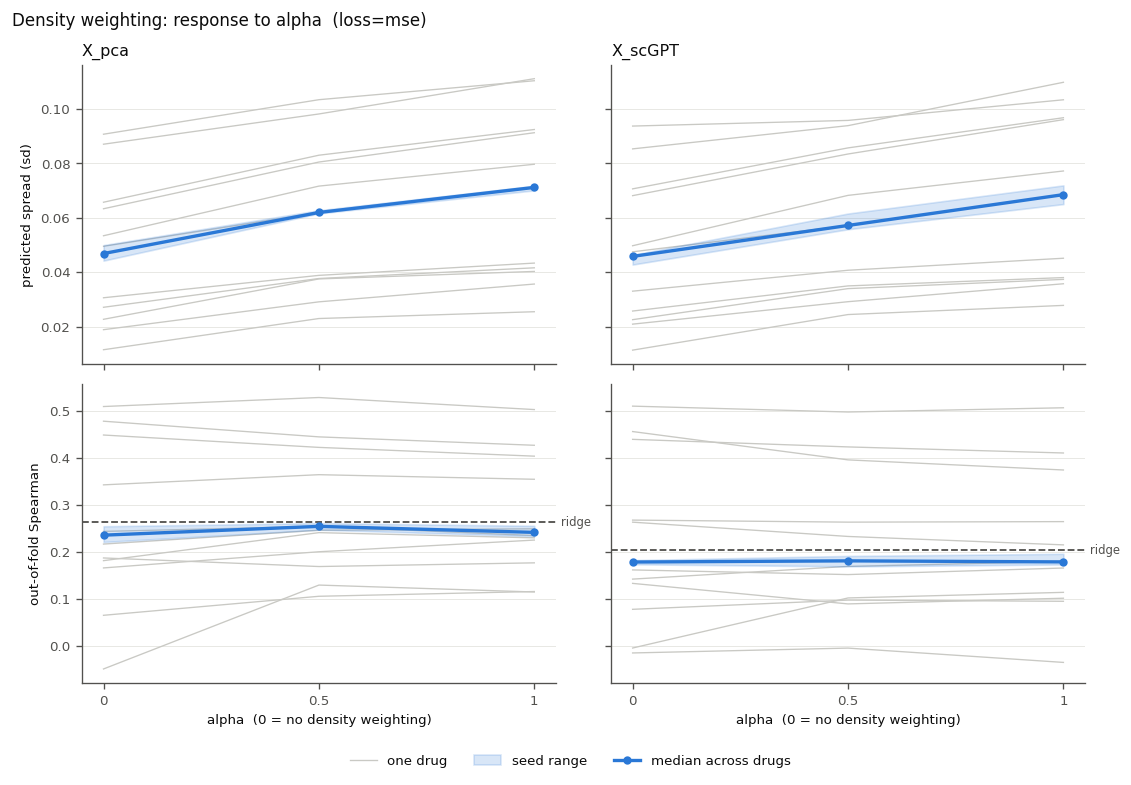

In [11]:
ACCENT, CONTEXT, INK, MUTED = '#2a78d6', '#c9c9c4', '#0b0b0b', '#52514e'
plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': MUTED, 'text.color': INK, 'axes.labelcolor': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'font.size': 8,
    'grid.color': '#e8e8e4', 'grid.linewidth': 0.6,
})

# Alpha-response curves, not a two-arm contrast (visualization agent, 13.08.2026). Rows = quantity,
# columns = representation. The faceting rather than colour-coding of the representation is what
# makes room for the SEED BAND, and the band is the one element that may not be dropped for tidiness:
# the item-9A margin is *defined* as the seed spread, so a figure without it invites exactly the
# misreading the rule exists to prevent -- an alpha-to-alpha step smaller than the noise, read off
# the plot as an effect.
QUANTITIES = [('pred_std', 'predicted spread (sd)'), ('spearman', 'out-of-fold Spearman')]

#: Perceptibility floor for the seed band, in TYPOGRAPHIC POINTS of rendered height. Chosen as 2 pt
#: (visualization agent, 13.08.2026) -- roughly the thinnest ribbon that still reads as a band rather
#: than a thick line. It guards LEGIBILITY, not correctness: the judgement the band supports ("is the
#: alpha-to-alpha step bigger than the seed spread?") compares two lengths inside one panel, so it is
#: scale-invariant and a shared y-axis cannot distort it. What a shared axis can do is shrink both
#: below the point where a reader can see either. When that happens the panel says so, exactly as it
#: does for a single seed, rather than inviting a squint at a ribbon.
#:
#: ⛔ IF THIS FIRES ON REAL R4 DATA, DO NOT LOWER IT. Lowering the floor converts a legibility warning
#: into silence, which is the same defect as drawing a zero-width band without comment -- the figure
#: would then assert a readability it does not have, and a guard tuned until it stops firing has been
#: deleted slowly. The correct response is an encoding change, which is the visualization agent's
#: call. 2.0 is a starting value, chosen rather than derived, so it is legitimate to revisit -- on
#: evidence about perceptibility, not because it is inconvenient.
#:
#: What governs whether it fires is the BETWEEN-DRUG spread, not the seed spread: the between-drug
#: spread sets the shared y-range, and a wider one at R4 shrinks a realistic seed band below the floor.
BAND_FLOOR_PT = 2.0
HAS_SEEDS = 'seed' in corr.columns and corr.seed.nunique() > 1

# sharey='row', not across the grid: two panels labelled by representation invite exactly one
# action -- comparing them -- and independent y-scales make that comparison read wrong
# (visualization agent, 13.08.2026). Per row, because pred_std and Spearman are different units.
fig, axes = plt.subplots(len(QUANTITIES), len(REPS), figsize=(4.7 * len(REPS), 6.4),
                         sharex=True, sharey='row', squeeze=False)
xs = np.arange(len(ALPHAS))
band_extents = {}          # ax -> (lo, hi) in data units, checked against the floor after layout
for j, rep in enumerate(REPS):
    sub = corr[corr.rep == rep]
    for i, (col, label) in enumerate(QUANTITIES):
        ax = axes[i][j]
        for k, d in enumerate(PANEL):                     # one faint line per drug (median over seeds)
            g = sub[sub.drug == d]
            ax.plot(xs, [g[g.alpha == a][col].median() for a in ALPHAS],
                    color=CONTEXT, linewidth=0.8, zorder=1,
                    label='one drug' if k == 0 else None)   # decode the mark in the legend, not the title
        med = [sub[sub.alpha == a][col].median() for a in ALPHAS]
        if HAS_SEEDS:                                     # band = spread of the across-drug median
            per_seed = [sub[sub.alpha == a].groupby('seed')[col].median() for a in ALPHAS]
            lo = [float(v.min()) for v in per_seed]
            hi = [float(v.max()) for v in per_seed]
            ax.fill_between(xs, lo, hi, color=ACCENT, alpha=0.18, zorder=2, label='seed range')
            band_extents[ax] = (lo, hi)
        else:
            ax.text(0.5, 0.04, 'single seed - no band drawn\nthe decision margin is not readable here',
                    transform=ax.transAxes, ha='center', va='bottom', fontsize=7, color='#b3261e',
                    linespacing=1.4,
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=1.5))
        ax.plot(xs, med, color=ACCENT, linewidth=2.0, marker='o', markersize=4, zorder=3,
                label='median across drugs')
        if col in ridge.columns:                          # ridge does not vary along alpha
            rv = ridge[ridge.rep == rep][col].median()
            # zorder above the faint drug lines, below the bold median; labelled at the right edge so
            # the reader is not tracing a dashed line through crossings.
            ax.axhline(rv, color=MUTED, linestyle='--', linewidth=1.1, zorder=2.5,
                       label='ridge baseline')
            ax.annotate('ridge', xy=(1.0, rv), xycoords=('axes fraction', 'data'),
                        xytext=(3, 0), textcoords='offset points', va='center',
                        fontsize=7, color=MUTED, annotation_clip=False)
        ax.set_xticks(xs)
        ax.set_xticklabels([f'{a:g}' for a in ALPHAS])
        ax.set_ylabel(label if j == 0 else '')
        ax.grid(axis='y')
        ax.set_axisbelow(True)
        if i == 0:
            ax.set_title(rep, loc='left', color=INK)
        if i == len(QUANTITIES) - 1:
            ax.set_xlabel('alpha  (0 = no density weighting)')
# Figure-level legend below the grid: inside the axes it overlapped the faint per-drug lines,
# which are the layer that shows within-drug movement. They stay faint on purpose -- the
# median and the band have to stay dominant -- so the legend moves instead.
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, fontsize=8, ncol=len(labels),
           loc='lower center', bbox_to_anchor=(0.5, -0.02))
# Title states what is held fixed and asserts no outcome -- the 27.07 conclusion this figure used to
# carry in its title is the very claim R4 re-tests.
fig.suptitle(f'Density weighting: response to alpha  (loss={config.loss})',
             x=0.005, ha='left', fontsize=10, color=INK)
fig.tight_layout(rect=(0, 0.03, 1, 1))

# Checked AFTER layout, because the rendered height of the band is not knowable before the axes have
# their final size. Reports the number it measured rather than only that it failed.
fig.canvas.draw()
for ax, (lo, hi) in band_extents.items():
    px = [abs(ax.transData.transform((0, h))[1] - ax.transData.transform((0, l))[1])
          for l, h in zip(lo, hi)]
    pts = float(np.median(px)) * 72.0 / fig.dpi
    if pts < BAND_FLOOR_PT:
        ax.text(0.5, 0.04,
                f'seed band renders at {pts:.1f} pt (floor {BAND_FLOOR_PT:g} pt)\n'
                f'too narrow to read here - take the margin from the table',
                transform=ax.transAxes, ha='center', va='bottom', fontsize=7, color='#b3261e',
                linespacing=1.4,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=1.5))

fig.savefig(OUT / 'panel_alpha_response.png')
plt.show()


## 6 · Reading the result

**No numbers are stated here.** They are in the tables above and in `outputs/panel/`; a second copy
in prose is the one that goes stale. This section says what the tables answer and how to read them.

### The decision rule (review item 9A)

The arms compete for one winner on **ranking** — mean per-drug Spearman across held-out lines. The
other three quantities are **non-inferiority guards**, each with its margin set to that quantity's
*own* seed band:

| quantity | role |
|---|---|
| Spearman | the criterion |
| MSE | guard — a ranking gain bought with a large calibration loss is not a win |
| predicted spread | guard, and the mechanism check for the weighting |
| out-of-fold null Δ | guard — an arm that does not beat the per-drug constant is not in the race |

**Why the band and not a threshold.** With three seeds every arm has a half-range. A step from one α
or loss to the next that is smaller than that band carries no information, whichever way it points.
The alpha-response figure draws the band for exactly this reason.

### Three things to check before reading anything else

1. **Did the weighting mechanism fire?** Predicted spread should *rise* with α — that is reduced
   shrinkage, what the weighting is for. If Spearman is flat while the spread moved, the answer is
   "not a lever here". If the spread did not move either, the weighting did not run as intended and
   nothing about it has been tested.
2. **Where does each arm's best epoch sit?** An arm peaking at epoch 1 is doing little more than the
   initialised null plus one pass — which is also what a linear model on line means delivers, so a
   ridge tie for that arm is mechanistic rather than surprising.
3. **Did ridge's penalty land on a grid endpoint** for one arm and not the other? If so the two
   arms were not regularized on comparable terms and the ridge comparison is not yet arm-fair.

### Dated observations from earlier runs — to check against, not to carry forward

> ⚠️ These describe the 13.07–14.07 runs, on a retired target and a void panel. They are recorded
> because they name *failure modes worth looking for*, not because they hold now.
>
> * The configuration was not bit-reproducible on `mps`, and **only the PCA arm moved** — four runs
>   of identical code and seed spanning ~0.007 Spearman. Deltas inside that band had no usable sign.
> * **PCA peaked at epoch 1** on four of five folds while scGPT kept improving for ten to twenty.
>   The alternative reading — that the learning rate suits one arm and not the other — was never
>   excluded.

### What this run does not settle

The panel is literature-anchored but not label-blind. The base quantity is still AUC, with its
potency/efficacy conflation and its unstandardised dose grid. And research question 2 — whether
heterogeneity is learned implicitly — is **structurally untestable here**: the label is constant
within a line, so the loss penalises any difference the model predicts between two cells of the same
line. That is what `4b` changes, and it is the only thing it changes.

---

# §B · PCA vs scGPT — the K=545 matrix

⛔ **Off by default (`RUN_SECTION_B = False`), and its conclusions are void.** The 8-run matrix and
the *"ρ ≈ 0, the model cannot rank cell lines"* reading were produced at K=545 on the retired
`mean_pv` target, whose unstandardised per-drug variance was destroying the signal
([why](../docs/steps/corrections-and-dead-ends.md#neither-representation-ranks-cell-lines--the-k545-null-result)).
**The machinery is not void** — only the numbers.

| | |
|---|---|
| **in** | `hvg5000` and `all_genes` targets, all 534 screened drugs |
| **out** | `outputs/archive/training_545_mean_pv/` — deliberately not §A's directory |

§A asks *how well does the panel model rank cell lines?*; §B asks *does the representation matter?*
Same folds, different question, which is why they share a notebook rather than a section.

**Why `cv_evaluate` and not `oof_predictions`.** Both now use the same head-bias initialisation and
the same `cv.grouped_folds`, so folds and model are identical across the sections; only the *return*
differs. §A needs predictions, §B needs per-fold metrics (`gap`, heads-beating) that
`oof_predictions` does not return.

## B1 · The 8-run matrix (load-or-train)

In [12]:
if not RUN_SECTION_B:
    print('RUN_SECTION_B is False -- section B skipped (see the setup cell).')
else:
    def find_run(rep, scope, variant, drugs):
        """Latest runs/ dir matching (rep, scope, variant, drugs) via run_meta.json."""
        hits = []
        for d in glob.glob('runs/*_multitask_*'):
            mp = Path(d) / 'run_meta.json'
            if not mp.exists():
                continue
            m = json.load(open(mp))
            if (m.get('rep') == rep and m.get('scope') == scope
                    and m.get('variant') == variant and m.get('drugs_requested') == drugs):
                hits.append(d)
        return sorted(hits)[-1] if hits else None

    def load_run(rd):
        rd = Path(rd)
        perdrug = rd / 'per_drug_results.csv'
        return {
            'run_dir': str(rd),
            'summary': json.load(open(rd / 'summary.json')),
            'meta': json.load(open(rd / 'run_meta.json')),
            'history': pd.read_csv(rd / 'history.csv'),
            'per_drug': pd.read_csv(perdrug) if perdrug.exists() else None,
        }

    results = {}
    for m in MATRIX:
        key = f"{m['variant']}|{m['rep']}|{m['task']}"
        scope = 'all_drugs' if m['task'] == 'all_drugs' else 'subset'
        rd = None if RETRAIN_MATRIX else find_run(m['rep'], scope, m['variant'], m['drugs'])
        if rd is None:
            print(f'training {key} ...')
            paths = PipelinePaths.build(None, m['variant'])
            res = train_rep(use_rep=m['rep'], h5ad_path=str(paths.targets_h5ad), config=config,
                            drugs=m['drugs'], data_root=paths.data_root, variant=m['variant'],
                            print_comparison=False)
            rd = res['run_dir']
        else:
            print(f'loading  {key} <- {Path(rd).name}')
        results[key] = load_run(rd)

RUN_SECTION_B is False -- section B skipped (see the setup cell).


### All-drugs (K=545) — heads beating the per-drug-mean baseline

In [13]:
if not RUN_SECTION_B:
    print('RUN_SECTION_B is False -- section B skipped (see the setup cell).')
else:
    rows = []
    for v in VARIANTS:
        for r in REPS:
            s = results[f'{v}|{r}|all_drugs']['summary']
            rows.append({'gene_set': v, 'rep': r, 'val_mse': round(s['best_val_mse'], 4),
                         'heads_beat_baseline': s['n_beats_baseline'], 'n_heads': s['n_total_heads'],
                         'baseline_mean_mse': round(s['baseline_mean_mse'], 4)})
    all_drugs_df = pd.DataFrame(rows)
    all_drugs_df.to_csv(OUT_MATRIX / 'matrix_all_drugs.csv', index=False)
    all_drugs_df

RUN_SECTION_B is False -- section B skipped (see the setup cell).


### Single-task (paclitaxel) — overfitting gap (val − train at best epoch)

In [14]:
if not RUN_SECTION_B:
    print('RUN_SECTION_B is False -- section B skipped (see the setup cell).')
else:
    rows = []
    for v in VARIANTS:
        for r in REPS:
            res = results[f'{v}|{r}|single_paclitaxel']
            h, be = res['history'], res['summary']['best_epoch']
            tr = float(h.loc[h.epoch == be, 'train_mse'].iloc[0])
            va = float(h.loc[h.epoch == be, 'val_mse'].iloc[0])
            rows.append({'gene_set': v, 'rep': r, 'train_mse': round(tr, 4),
                         'val_mse': round(va, 4), 'gap_val_minus_train': round(va - tr, 4),
                         'best_epoch': be})
    single_df = pd.DataFrame(rows)
    single_df.to_csv(OUT_MATRIX / 'matrix_single_paclitaxel.csv', index=False)
    single_df

RUN_SECTION_B is False -- section B skipped (see the setup cell).


### Per-drug scatter (hvg5000, all drugs) — points below diagonal: scGPT beats PCA

In [15]:
if not RUN_SECTION_B:
    print('RUN_SECTION_B is False -- section B skipped (see the setup cell).')
else:
    pca_pd = results['hvg5000|X_pca|all_drugs']['per_drug'].set_index('drug')
    scg_pd = results['hvg5000|X_scGPT|all_drugs']['per_drug'].set_index('drug')
    common = pca_pd.index.intersection(scg_pd.index)
    pca_mse = pca_pd.loc[common, 'model_val_mse'].to_numpy()
    scg_mse = scg_pd.loc[common, 'model_val_mse'].to_numpy()
    finite = np.isfinite(pca_mse) & np.isfinite(scg_mse)
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.scatter(pca_mse[finite], scg_mse[finite], s=10, alpha=0.5)
    lim = [0, np.nanmax(np.r_[pca_mse[finite], scg_mse[finite]]) * 1.05]
    ax.plot(lim, lim, 'k--', lw=1, label='y = x'); ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('PCA per-drug val MSE'); ax.set_ylabel('scGPT per-drug val MSE')
    ax.set_title('hvg5000 · per-drug val MSE — scGPT vs PCA'); ax.legend()
    fig.tight_layout(); fig.savefig(OUT_MATRIX / 'per_drug_scatter_pca_vs_scgpt.png', dpi=150); plt.show()
    print(f'scGPT beats PCA on {int((scg_mse[finite] < pca_mse[finite]).sum())} / {int(finite.sum())} heads.')

RUN_SECTION_B is False -- section B skipped (see the setup cell).


## B2 · Is the difference real? — 5-fold `GroupKFold`

| | |
|---|---|
| **in** | the 153 train+val lines of `hvg5000`; the fixed test set is untouched |
| **out** | mean ± std per configuration, in place of the single-split point estimates above |

**Why grouping is by cell line.** Viability is defined per (cell line × drug) and broadcast to that
line's cells, so a per-cell split would put the same label on both sides of it.

**Why the split sizes are not written here.** They are printed by the cell below and stored in the
split artifact; a copy in prose is what goes stale when eligibility moves — and eligibility *does*
move whenever the response source or `--min-cell-lines` changes.

**How CV nests inside the split.** The test lines are held out of CV entirely. `GroupKFold(5)`
resamples only the train+val lines; within each fold a further 15 % of the fitting lines is withheld
for early stopping (`cv.inner_holdout`), so the fold being scored never chooses the checkpoint that
predicts it. Until 12.08.2026 early stopping watched the scored fold itself —
[Step 03](../docs/steps/03-model-and-training-design.md#the-early-stopping-set-is-nested-inside-the-training-lines-12082026).

**Reading the columns** (definitions: `../docs/steps/05-multitask-results.md` → *Metrics*):

| column | what it is |
|---|---|
| `heads_beat` | count of drugs whose val MSE beats their per-drug-mean baseline — **thresholded**, hence the large fold-to-fold std |
| `Δmse model−baseline` | the **continuous** counterpart, mean over drugs; `< 0` ⇒ model better; far more stable |
| `val_mse` | masked MSE on the **early-stopping slice** — it chose the epoch, it is not a score on the held-out fold |
| `gap` | early-stopping minus fitting MSE at that epoch (overfitting) |

In [16]:
if not RUN_SECTION_B:
    print('RUN_SECTION_B is False -- section B skipped (see the setup cell).')
else:
    CV_SPLITS = ('train', 'val')        # test held out of CV
    cv = {}   # (rep, task) -> list of per-fold dicts
    if not RECOMPUTE_CV and (OUT_MATRIX / 'cv_folds.csv').exists():
        _cl = pd.read_csv(OUT_MATRIX / 'cv_folds.csv')
        for (rep, task), g in _cl.groupby(['rep', 'task']):
            cv[(rep, task)] = g.to_dict('records')
        print('Loaded CV from outputs/archive/training_545_mean_pv/cv_folds.csv (set RECOMPUTE_CV=True to rerun).')
    else:
        # Same defect as section A, and fixed the same way (13.08.2026): both calls omitted
        # counts_h5ad, so flipping RECOMPUTE_CV to True raised on rep='X_pca'. Section B pins the
        # variant to hvg5000, so its counts file is that variant's -- bound once here rather than
        # rebuilt per call, so the targets and the counts cannot come from different variants.
        _paths_b = PipelinePaths.build(None, 'hvg5000')
        adata_hvg = sc.read_h5ad(_paths_b.targets_h5ad)
        for rep in REPS:
            cv[(rep, 'all_drugs')] = cv_evaluate(adata=adata_hvg, use_rep=rep, config=config,
                                                 n_splits=N_CV_SPLITS, drugs=None,
                                                 counts_h5ad=_paths_b.raw_h5ad,
                                                 eligible_splits=CV_SPLITS)
            cv[(rep, 'paclitaxel')] = cv_evaluate(adata=adata_hvg, use_rep=rep, config=config,
                                                  n_splits=N_CV_SPLITS, drugs=['paclitaxel'],
                                                  counts_h5ad=_paths_b.raw_h5ad,
                                                  eligible_splits=CV_SPLITS)
        print('CV done (test held out).')

RUN_SECTION_B is False -- section B skipped (see the setup cell).


In [17]:
if not RUN_SECTION_B:
    print('RUN_SECTION_B is False -- section B skipped (see the setup cell).')
else:
    def ms(vals):
        a = np.asarray(vals, float); return a.mean(), a.std()

    rows = []
    for rep in REPS:
        ad_folds = cv[(rep, 'all_drugs')]
        hb = [f['n_beats'] for f in ad_folds]
        vm = [f['best_val_mse'] for f in ad_folds]
        # continuous delta = mean per-drug (model − baseline) MSE; <0 means model beats the constant
        delta = [f['model_mean_mse'] - f['baseline_mean_mse'] for f in ad_folds]
        gap = [f['gap'] for f in cv[(rep, 'paclitaxel')]]
        hb_m, hb_s = ms(hb); vm_m, vm_s = ms(vm); d_m, d_s = ms(delta); g_m, g_s = ms(gap)
        n_tot = ad_folds[0]['n_total']
        rows.append({'rep': rep,
                     'heads_beat (mean±std)': f'{hb_m:.0f} ± {hb_s:.0f} / {n_tot}',
                     'Δmse model−baseline (mean±std)': f'{d_m:+.5f} ± {d_s:.5f}',
                     'all_drugs val_mse (mean±std)': f'{vm_m:.4f} ± {vm_s:.4f}',
                     'paclitaxel gap (mean±std)': f'{g_m:+.3f} ± {g_s:.3f}'})
    cv_summary = pd.DataFrame(rows)
    # tidy per-fold dump too
    cv_long = pd.DataFrame([{**f, 'task': t[1], 'rep': t[0]} for t, fl in cv.items() for f in fl])
    cv_long.to_csv(OUT_MATRIX / 'cv_folds.csv', index=False)
    cv_summary.to_csv(OUT_MATRIX / 'cv_summary.csv', index=False)
    cv_summary

RUN_SECTION_B is False -- section B skipped (see the setup cell).


## B3 · Per-drug correlation across held-out lines

| | |
|---|---|
| **in** | the loaded `hvg5000` all-drugs runs, scored on the `split_ctrp` val lines |
| **out** | Spearman and Pearson per drug, predicted vs true per-line response |

**Why correlation rather than MSE here.** Near a viability of ~1.0 the MSE is dominated by the
constant, so it barely distinguishes a model that ranks lines from one that does not.

Restricted to drugs with real response variance (per-line true sd ≥ `MIN_VAR_STD`) and at least 5
val lines — a correlation over a flat or near-empty set is noise with a number attached.

In [18]:
if not RUN_SECTION_B:
    print('RUN_SECTION_B is False -- section B skipped (see the setup cell).')
else:
    if 'adata_hvg' not in globals():
        adata_hvg = sc.read_h5ad(PipelinePaths.build(None, 'hvg5000').targets_h5ad)
    val_mask = (adata_hvg.obs['split_ctrp'] == 'val').to_numpy()
    lines_v = adata_hvg.obs['Cell_line'].astype(str).to_numpy()[val_mask]
    Yv = np.asarray(adata_hvg.obsm['Y_ctrp'], dtype=float)[val_mask]
    Mv = np.asarray(adata_hvg.obsm['M_ctrp'], dtype=bool)[val_mask]
    drug_names = list(adata_hvg.uns['ctrp_drugs'])
    uniq_lines = np.unique(lines_v)
    line_idx = {ln: np.flatnonzero(lines_v == ln) for ln in uniq_lines}

    def per_line_pred(model, rep):
        X = torch.tensor(np.asarray(adata_hvg.obsm[rep], dtype=np.float32)[val_mask])
        with torch.no_grad():
            return model(X).numpy()                  # (n_val_cells, K)

    def load_model(rd):
        m = json.load(open(Path(rd) / 'run_meta.json'))
        net = OncoMLP(input_dim=m['input_dim'], hidden_dims=tuple(m['hidden_dims']),
                      dropout_rate=m['dropout_rate'], input_dropout=m['input_dropout'],
                      norm=m['norm'], output_dim=m['output_dim'])
        net.load_state_dict(torch.load(Path(rd) / 'best_model.pt', map_location='cpu'))
        net.eval(); return net

    corr_tables = {}
    for rep in REPS:
        pred = per_line_pred(load_model(results[f'hvg5000|{rep}|all_drugs']['run_dir']), rep)
        recs = []
        for k, drug in enumerate(drug_names):
            tline, pline = [], []
            for ln in uniq_lines:
                ci = line_idx[ln]
                obs = ci[Mv[ci, k]]
                if obs.size == 0:
                    continue
                tline.append(Yv[obs, k].mean()); pline.append(pred[obs, k].mean())
            tline, pline = np.array(tline), np.array(pline)
            if tline.size < 5 or tline.std() < MIN_VAR_STD:
                continue
            recs.append({'drug': drug, 'n_lines': tline.size,
                         'spearman': spearmanr(pline, tline).statistic,
                         'pearson': pearsonr(pline, tline)[0],
                         'true_std': tline.std()})
        corr_tables[rep] = pd.DataFrame(recs)

    corr_summary = pd.DataFrame([
        {'rep': rep, 'n_drugs_eval': len(corr_tables[rep]),
         'mean_spearman': round(corr_tables[rep]['spearman'].mean(), 3),
         'median_spearman': round(corr_tables[rep]['spearman'].median(), 3),
         'mean_pearson': round(corr_tables[rep]['pearson'].mean(), 3),
         'frac_spearman>0.3': round((corr_tables[rep]['spearman'] > 0.3).mean(), 3)}
        for rep in REPS])
    for rep in REPS:
        corr_tables[rep].to_csv(OUT_MATRIX / f'per_drug_correlation_{rep}.csv', index=False)
    corr_summary.to_csv(OUT_MATRIX / 'per_drug_correlation_summary.csv', index=False)
    corr_summary

RUN_SECTION_B is False -- section B skipped (see the setup cell).


In [19]:
if not RUN_SECTION_B:
    print('RUN_SECTION_B is False -- section B skipped (see the setup cell).')
else:
    fig, ax = plt.subplots(figsize=(6.5, 4))
    for rep in REPS:
        s = corr_tables[rep]['spearman'].dropna().sort_values().to_numpy()
        ax.plot(s, np.linspace(0, 1, len(s)), label=f'{rep} (n={len(s)})')
    ax.axvline(0, color='k', lw=0.6); ax.set_xlabel('per-drug Spearman (pred vs true, across lines)')
    ax.set_ylabel('cumulative fraction of drugs'); ax.set_title('Per-drug rank correlation — PCA vs scGPT')
    ax.legend(); fig.tight_layout(); fig.savefig(OUT_MATRIX / 'per_drug_correlation_cdf.png', dpi=150); plt.show()

RUN_SECTION_B is False -- section B skipped (see the setup cell).


## B · Outputs

In [20]:
if not RUN_SECTION_B:
    print('RUN_SECTION_B is False -- section B skipped (see the setup cell).')
else:
    # This cell reported no files while 10 CSVs and 4 PNGs sat in section B's directory. Broken since
    # B's writes were repointed into legacy/; NOT introduced by the OUT_MATRIX fix in f6cbef4, which
    # left the glob equally empty. The stored output below predates the repointing and names the flat
    # outputs/matrix_*.csv paths B used before it.
    #
    # Fixed twice, independently, and reconciled here (12.08.2026). One fix introduced
    # B_OUT = OUT_MATRIX / 'legacy' / 'training_545_mean_pv', correct while OUT_MATRIX meant
    # notebooks/outputs; the other made OUT_MATRIX mean the directory it is named for and stripped the
    # suffix from all ten call sites above. Both landed, so B_OUT re-appended a suffix OUT_MATRIX
    # already contained and the glob pointed two levels too deep -- a clean rebase producing a broken
    # path. B_OUT is redundant under the consolidation and is gone; the glob uses OUT_MATRIX directly,
    # which is the point of naming it for the directory it means.
    for p in sorted(OUT_MATRIX.glob('*.csv')) + sorted(OUT_MATRIX.glob('*.png')):
        print(' ', p.relative_to(ROOT))

RUN_SECTION_B is False -- section B skipped (see the setup cell).


---

# §C · Capacity — is the trunk deciding the representation comparison?

✅ **On, and it stays on — decided 14.08.2026 (Selin).** `RUN_SECTION_C = True` is what produced the
stored outputs below, and a notebook whose committed flags do not reproduce its committed outputs is
the defect class this review spent a week finding. The cost is wall-clock and is recoverable; the
alternative costs reproducibility and is not. It adds 60 fits (of 330) to a full run. §A is untouched
by it.

| | |
|---|---|
| **in** | the same panel, folds, PCA seed and eligible cells as §A |
| **out** | `panel_arch_oof.csv`, `panel_arch_folds.csv` — one row per (arch, rep, loss, seed, …) |

**The question.** §A trains a `(128, 64)` trunk with 75,019 parameters. The label is constant within
a cell line, so the 40,000 training cells are repetitions of ~104 values — the effective sample is
the number of *lines*, not of cells. §A's own fold log shows what that does: `X_pca` reaches its
best epoch at a **median of 2**, `X_scGPT` at **8**. The two arms are therefore in different training
regimes, and "which representation is better" is entangled with "which representation this fixed
trunk happens to suit".

**What this section changes, and only this.** The trunk, to `hidden_dims = ()` — which `OncoMLP`
resolves to `Dropout(0.1) → Linear(512, K)`, 5,643 parameters, a factor of 13 smaller. Everything
else is the object §A used: the same `oof_predictions`, the same `cv.grouped_folds` partition, the
same panel, the same seeds. Scope agreed 12.08.2026 (Selin): *"trunk (128,64) vs a bare linear head,
both representations, against RidgeCV on the same folds"* — not the four-knob sweep.

**Why both losses and only `alpha = 0`.** The loss axis did not exist when the scope was set, and it
is not neutral here: on `X_scGPT` MAE beats MSE by up to +0.047, more than the effect this section is
built to measure, so fixing one loss would make the answer depend on which. `alpha` is held at 0
because §A measured it to be a nuisance for this question — at `alpha = 1` `X_scGPT` falls *below*
the per-drug constant (Δ against the out-of-fold null: −0.0002 / −0.0004).

**What a result would mean.** If the linear head closes or reverses the gap, the trunk was carrying
the comparison and `RidgeCV` is not a baseline that happens to bind but the appropriate model for
~104 examples. If the gap survives, the representation is doing the work and the trunk is exonerated.

In [21]:
# ⚠️ FALSE by default. §C is a control, not part of the panel run: it re-trains the whole
# §A design at a second capacity, so leaving it on would double every future execution of this
# notebook for a question that is asked once.
RUN_SECTION_C = True

# The two capacities. `()` is not a special case in OncoMLP -- the hidden-layer loop simply does not
# execute, leaving Dropout(input_dropout) -> Linear(input_dim, K). Checked rather than assumed below.
ARCHS = {'linear': (), 'trunk': (128, 64)}

# Held fixed, and each for a measured reason rather than by default:
#   alpha=0   -- the SIMPLEST objective, chosen so the capacity effect is read without a second
#                intervention on top of it. ⚠️ It is NOT the best-performing level: §A measured
#                alpha=0.5 to beat alpha=0 on X_pca by +0.021 in BOTH losses, each outside that
#                arm's seed band, while doing nothing or harm on X_scGPT
#                (corrections-and-dead-ends.md, the inverse-density entry, 13.08.2026).
#                So §C answers "does the trunk carry Q1 at alpha=0", not "at the best alpha" --
#                and if the capacity effect turns out to interact with alpha, that is a second run,
#                not a reinterpretation of this one. What IS settled: alpha=1 puts X_scGPT below
#                the per-drug constant, so the axis has one level that is simply out.
#   loss=mse  -- MAE was RETIRED as a competing arm (Selin, 13.08.2026) after §A measured that its
#                advantage is entangled with the very term §C's successor isolates: absolute error
#                relaxes the within-line variance penalty wherever a line's predictions do not
#                straddle its label, and it left 25 % more within-line spread standing on X_scGPT
#                (none on X_pca). Squared error is kept because it is the one objective whose
#                behaviour can be STATED: only under it does 4a differ from 4b by exactly Var_c(p).
#                §C therefore runs under the objective the project keeps, not under both.
#                One constant restores the robustness check: ARCH_LOSSES = LOSSES.
#   SEEDS, PANEL, N_SPLITS, PCA_SEED, REPS -- the §A objects, imported by being the same variables.
#                A margin here is judged against the same seed band as §A's, so it must be the same
#                seed set, and the fold partition must be the same partition.
ARCH_ALPHA = 0.0
ARCH_LOSSES = ('mse',)

OUT_ARCH = OUT                # §C writes beside §A, under its own file names
ARCH_OOF_CSV = OUT_ARCH / 'panel_arch_oof.csv'
ARCH_FOLDS_CSV = OUT_ARCH / 'panel_arch_folds.csv'

# The claim the section rests on, asserted rather than described: an empty trunk really is a bare
# linear head, and it really is the smaller model. If OncoMLP's constructor ever changes shape, this
# fails here instead of producing a "capacity comparison" between two identical networks.
_probe = {name: OncoMLP(input_dim=512, hidden_dims=h, output_dim=len(PANEL))
          for name, h in ARCHS.items()}
_n_par = {name: sum(q.numel() for q in m.parameters()) for name, m in _probe.items()}
assert len([m for m in _probe['linear'].network if isinstance(m, torch.nn.Linear)]) == 1, \
    "hidden_dims=() must leave exactly one Linear -- OncoMLP's layer construction has changed"
assert _n_par['linear'] < _n_par['trunk'] / 5, \
    f"the 'linear' arm is not materially smaller: {_n_par}"

print(f'section C: {"ON" if RUN_SECTION_C else "OFF"}')
print(f'  architectures : ' + ', '.join(f'{k} {v} -> {_n_par[k]:,} params'
                                        for k, v in ARCHS.items()))
print(f'  losses        : {list(ARCH_LOSSES)}   alpha = {ARCH_ALPHA:g}')
print(f'  seeds         : {list(SEEDS)}   folds = {N_SPLITS}   panel = {len(PANEL)} drugs')
print(f'  fits          : {len(ARCHS)} x {len(REPS)} x {len(ARCH_LOSSES)} x {len(SEEDS)} x {N_SPLITS}'
      f' = {len(ARCHS) * len(REPS) * len(ARCH_LOSSES) * len(SEEDS) * N_SPLITS}')
del _probe

section C: ON
  architectures : linear () -> 5,643 params, trunk (128, 64) -> 75,019 params
  losses        : ['mse']   alpha = 0
  seeds         : [42, 43, 44]   folds = 5   panel = 11 drugs
  fits          : 2 x 2 x 1 x 3 x 5 = 60


## C1 · The grid — one axis added, everything else held

| | |
|---|---|
| **out** | `panel_arch_oof.csv` — line-level predictions, one row per (arch, rep, loss, seed, drug, line) |
| | `panel_arch_folds.csv` — one row per fit, carrying `best_epoch` |

**Why `best_epoch` is written and not just the score.** It is the quantity that raised the question:
§A reached its best checkpoint at a median of epoch 2 on `X_pca` and 8 on `X_scGPT`. If the linear
head puts the two arms in the *same* regime, that is itself the finding, whether or not the scores
move — a comparison between two representations is only a comparison if the model can train on both.

**What is asserted rather than trusted.** That `paths` still points at this section's variant (§B
reassigns it, and would silently redirect §C's per-fold PCA to another gene set), and that the fold
partition is the one §A used — otherwise "same folds" is a claim in the prose and not in the run.

In [22]:
if not RUN_SECTION_C:
    print('RUN_SECTION_C is False -- skipping the capacity control (see the knobs cell).')
else:
    # §B reassigns `paths` to whatever variant it last touched. §C reads paths.raw_h5ad for the
    # per-fold PCA, so a §B run in the same kernel would refit the representation on another gene
    # set while every label and every fold stayed the same -- a comparison that runs and means
    # nothing. Cheap to check, impossible to notice in the output.
    assert paths.variant == VARIANT, (
        f'paths points at {paths.variant!r}, not {VARIANT!r} -- section B has reassigned it. '
        f'Re-run the section A setup cell before running C.')

    arch_oof, arch_log = {}, []
    for arch, dims in ARCHS.items():
        for rep in REPS:
            for loss in ARCH_LOSSES:
                for seed in SEEDS:
                    # Identical to §A's call except for `hidden_dims`. That is the whole design: the
                    # panel, the folds, the PCA seed, the head-bias init and the optimizer are the
                    # same objects, so a difference between the two architectures is attributable to
                    # the architecture. `dims=()` reaches OncoMLP as "no hidden layer" -- cv.py
                    # distinguishes it from None since 13.08.2026; under the previous `or` it was
                    # falsy and would have silently become (128, 64).
                    pred, folds = oof_predictions(
                        adata, rep, PANEL,
                        config=replace(config, seed=seed, loss=loss),
                        hidden_dims=dims, n_splits=N_SPLITS,
                        density_weighting=ARCH_ALPHA > 0, alpha=ARCH_ALPHA,
                        init_head_bias=True,
                        counts_h5ad=paths.raw_h5ad, pca_seed=PCA_SEED,
                        tag=f'C_{arch}_{rep}_{loss}_s{seed}')
                    arch_oof[(arch, rep, loss, seed)] = (pred, folds)
                    arch_log.extend([{**f, 'arch': arch, 'model': 'mlp',
                                      'alpha': ARCH_ALPHA, 'loss': loss, 'seed': seed}
                                     for f in folds])
                    print(f'== done {arch:6s} {rep:8s} loss={loss} seed={seed}')

    arch_tidy = pd.concat(
        [line_level_predictions(pred, adata, PANEL, folds=folds, rep=rep, model='mlp',
                                alpha=ARCH_ALPHA, loss=loss, seed=seed, arch=arch)
         for (arch, rep, loss, seed), (pred, folds) in arch_oof.items()], ignore_index=True)
    arch_tidy.to_csv(ARCH_OOF_CSV, index=False)

    arch_folds = pd.DataFrame(arch_log)
    arch_folds.to_csv(ARCH_FOLDS_CSV, index=False)

    # "Same folds as section A" is a claim about the run, so it is checked in the run. grouped_folds
    # is deterministic given (adata, n_splits), but §A's log is the only evidence that this kernel
    # produced the same partition -- and if §A was not executed here there is nothing to compare to,
    # which is reported rather than passed over in silence.
    _key = ['fold', 'rep']
    if 'fold_log' in globals() and len(fold_log):
        _a = (pd.DataFrame(fold_log).drop_duplicates(_key).set_index(_key)['val_lines'])
        _c = (arch_folds.drop_duplicates(_key).set_index(_key)['val_lines'])
        _both = _a.index.intersection(_c.index)
        assert len(_both) and (_a.loc[_both] == _c.loc[_both]).all(), \
            'section C is not on section A\'s fold partition -- the two are not comparable'
        print(f'\nfold partition: identical to section A on all {len(_both)} (fold, rep) pairs')
    else:
        print('\nfold partition: section A was not run in this kernel -- not cross-checked')

    print(f'{len(arch_oof)} arms x {pred.shape} per-cell predictions')
    print(f'{len(arch_tidy):,} line-level rows -> {ARCH_OOF_CSV.name}')
    print('\nbest epoch per arm (the regime, not the score):')
    print(arch_folds.groupby(['arch', 'rep', 'loss'])['best_epoch']
          .agg(median='median', min='min', max='max').to_string())

Loaded 27516 cells for the 'custom-mask' set. K=11 drugs | mean drugs/cell=10.8 | min drug coverage=25977 cells | max drug coverage=27516 cells.
Loaded 5210 cells for the 'custom-mask' set. K=11 drugs | mean drugs/cell=10.4 | min drug coverage=4347 cells | max drug coverage=5210 cells.
[C_linear_X_pca_mse_s42_f1] Training on device: mps
[C_linear_X_pca_mse_s42_f1] Multi-task mode detected (masked MSE).
[C_linear_X_pca_mse_s42_f1] Weight decay 0 on 5632 weight parameters; 11 bias/norm parameters exempt.


[C_linear_X_pca_mse_s42_f1] Epoch [01/50] | Train MSE: 0.1112 | Val MSE: 0.0162 | LR: 1.0e-03  <- best
  best : imatinib:0.004(n=4881), platin:0.005(n=5210), crizotinib:0.006(n=4881), etoposide:0.008(n=4678), erlotinib:0.009(n=4881)
  worst: gemcitabine:0.058(n=5210), paclitaxel:0.030(n=5210), doxorubicin:0.019(n=5210), dasatinib:0.015(n=4881), sorafenib:0.010(n=4881)


[C_linear_X_pca_mse_s42_f1] Epoch [03/50] | Train MSE: 0.0048 | Val MSE: 0.0162 | LR: 1.0e-03  <- best
  best : imatinib:0.004(n=4881), platin:0.005(n=5210), crizotinib:0.005(n=4881), erlotinib:0.008(n=4881), etoposide:0.009(n=4678)
  worst: gemcitabine:0.058(n=5210), paclitaxel:0.031(n=5210), doxorubicin:0.019(n=5210), dasatinib:0.014(n=4881), sorafenib:0.011(n=4881)


[C_linear_X_pca_mse_s42_f1] Epoch [05/50] | Train MSE: 0.0053 | Val MSE: 0.0179 | LR: 1.0e-03
  best : platin:0.005(n=5210), imatinib:0.005(n=4881), crizotinib:0.007(n=4881), erlotinib:0.010(n=4881), etoposide:0.011(n=4678)
  worst: gemcitabine:0.060(n=5210), paclitaxel:0.032(n=5210), doxorubicin:0.024(n=5210), dasatinib:0.015(n=4881), sorafenib:0.013(n=4881)


[C_linear_X_pca_mse_s42_f1] Epoch [08/50] | Train MSE: 0.0044 | Val MSE: 0.0162 | LR: 5.0e-04  <- best
  best : platin:0.005(n=5210), imatinib:0.005(n=4881), crizotinib:0.005(n=4881), etoposide:0.007(n=4678), erlotinib:0.009(n=4881)
  worst: gemcitabine:0.060(n=5210), paclitaxel:0.030(n=5210), doxorubicin:0.017(n=5210), dasatinib:0.015(n=4881), afatinib:0.010(n=4347)


...

[C_trunk_X_scGPT_mse_s44_f5] Epoch [08/50] | Train MSE: 0.0105 | Val MSE: 0.0219 | LR: 1.0e-03  <- best
  best : platin:0.002(n=5302), sorafenib:0.005(n=5323), imatinib:0.006(n=5302), crizotinib:0.009(n=5599), dasatinib:0.012(n=5323)
  worst: gemcitabine:0.096(n=5302), paclitaxel:0.041(n=5323), doxorubicin:0.032(n=5599), afatinib:0.013(n=5106), etoposide:0.013(n=5323)


[C_trunk_X_scGPT_mse_s44_f5] Epoch [10/50] | Train MSE: 0.0099 | Val MSE: 0.0241 | LR: 1.0e-03
  best : platin:0.002(n=5302), sorafenib:0.006(n=5323), imatinib:0.008(n=5302), crizotinib:0.009(n=5599), dasatinib:0.012(n=5323)
  worst: gemcitabine:0.105(n=5302), paclitaxel:0.049(n=5323), doxorubicin:0.035(n=5599), etoposide:0.015(n=5323), afatinib:0.014(n=5106)


[C_trunk_X_scGPT_mse_s44_f5] Epoch [15/50] | Train MSE: 0.0089 | Val MSE: 0.0249 | LR: 5.0e-04
  best : platin:0.002(n=5302), sorafenib:0.005(n=5323), imatinib:0.007(n=5302), crizotinib:0.009(n=5599), erlotinib:0.012(n=5599)
  worst: gemcitabine:0.109(n=5302), paclitaxel:0.057(n=5323), doxorubicin:0.032(n=5599), etoposide:0.015(n=5323), dasatinib:0.013(n=5323)


[C_trunk_X_scGPT_mse_s44_f5] Early stopping at epoch 18 (no val improvement for 10 epochs).
[C_trunk_X_scGPT_mse_s44_f5] Training complete. Best Val MSE: 0.0219 at epoch 8.
== done trunk  X_scGPT  loss=mse seed=44



fold partition: identical to section A on all 10 (fold, rep) pairs
12 arms x (53513, 11) per-cell predictions
19,620 line-level rows -> panel_arch_oof.csv

best epoch per arm (the regime, not the score):
                     median  min  max
arch   rep     loss                  
linear X_pca   mse     12.0    1   23
       X_scGPT mse      2.0    1   18
trunk  X_pca   mse      1.0    1   10
       X_scGPT mse      8.0    1   15


## C2 · Reading it — does the trunk decide Q1?

| | |
|---|---|
| **in** | `panel_arch_oof.csv`, `panel_arch_folds.csv`, and §A's committed ridge baseline |
| **out** | `panel_arch_summary.csv` — one row per (arch, rep): mean Spearman, seed band, margins |

Three comparisons, and each is read against the **seed band** rather than against zero, because a
step smaller than the band carries no information whichever way it points:

1. **linear − trunk, within a representation.** Whether capacity is doing the work.
2. **PCA − scGPT, within an architecture.** Q1, asked twice. If the sign or the size moves between
   the two architectures, §A's answer was partly the trunk's.
3. **each arm − ridge.** Ridge fits 513 parameters per drug on ~104 lines. If a 5,643-parameter
   linear head lands on it, that is the honest ceiling for this sample size, not a baseline that
   happens to bind.

**The trunk arm is a replicate, and that is deliberate.** It repeats §A's `alpha=0`, `mse`
configuration exactly — same folds, same seeds, same everything. Its deviation from §A therefore
measures this configuration's run-to-run nondeterminism on `mps`, which is what calibrates how large
the linear-vs-trunk difference has to be before it means anything. A control that costs nothing
because those fits had to run regardless.

In [23]:
if not RUN_SECTION_C:
    print('RUN_SECTION_C is False -- nothing to read.')
else:
    def _per_drug(df, keys):
        recs = []
        for k, g in df.groupby(keys, sort=False):
            for d, gd in g.groupby('drug', sort=False):
                t, q = gd['y_true'].to_numpy(), gd['y_pred'].to_numpy()
                if t.size < 5 or t.std() == 0:
                    continue
                recs.append({**dict(zip(keys, k if isinstance(k, tuple) else (k,))),
                             'drug': d, 'spearman': spearmanr(q, t).statistic,
                             'mse': float(((q - t) ** 2).mean())})
        return pd.DataFrame(recs)

    arch_corr = _per_drug(arch_tidy, ['arch', 'rep', 'loss', 'seed'])

    # mean over drugs per seed, then the band across seeds -- the same construction section A uses,
    # so the two are read on one scale.
    _per_seed = arch_corr.groupby(['arch', 'rep', 'seed'])['spearman'].mean().reset_index()
    arch_summary = (_per_seed.groupby(['arch', 'rep'])['spearman']
                    .agg(mean='mean', lo='min', hi='max').reset_index())
    arch_summary['band'] = (arch_summary.hi - arch_summary.lo) / 2

    ridge_ref = pd.read_csv(OUT / 'panel_ridge_baseline.csv').groupby('rep')['spearman'].mean()
    arch_summary['ridge'] = arch_summary.rep.map(ridge_ref)
    arch_summary['minus_ridge'] = arch_summary['mean'] - arch_summary['ridge']
    arch_summary.to_csv(OUT / 'panel_arch_summary.csv', index=False)

    print('mean per-drug Spearman, out-of-fold, over the '
          f'{arch_corr.drug.nunique()} panel drugs:')
    print(arch_summary.round(4).to_string(index=False))

    _m = arch_summary.set_index(['arch', 'rep'])

    print('\n1 · capacity  (linear - trunk), against the wider of the two seed bands:')
    for rep in REPS:
        d = _m.loc[('linear', rep), 'mean'] - _m.loc[('trunk', rep), 'mean']
        b = max(_m.loc[('linear', rep), 'band'], _m.loc[('trunk', rep), 'band'])
        print(f'   {rep:10s} {d:+.4f}   band +/-{b:.4f}   '
              f'{"OUTSIDE the band" if abs(d) > b else "inside the band -- no information"}')

    print('\n2 · Q1  (X_pca - X_scGPT), asked once per architecture:')
    for arch in ARCHS:
        d = _m.loc[(arch, 'X_pca'), 'mean'] - _m.loc[(arch, 'X_scGPT'), 'mean']
        b = max(_m.loc[(arch, 'X_pca'), 'band'], _m.loc[(arch, 'X_scGPT'), 'band'])
        print(f'   {arch:6s} {d:+.4f}   band +/-{b:.4f}   '
              f'{"OUTSIDE the band" if abs(d) > b else "inside the band -- no information"}')
    print('   A sign or size that moves between the two rows means section A\'s Q1 answer was '
          'carried in part by the trunk.')

    print('\n3 · against ridge on line means (513 params per drug, ~104 lines):')
    for (arch, rep), r in _m.iterrows():
        print(f'   {arch:6s} {rep:10s} {r["minus_ridge"]:+.4f}   band +/-{r["band"]:.4f}   '
              f'{"clears ridge" if r["minus_ridge"] > r["band"] else "does not clear ridge"}')

    # The replicate: section C's trunk repeats section A's alpha=0 / mse configuration exactly.
    if 'corr' in globals() and 'seed' in corr.columns:
        _a = (corr[(corr.alpha == ARCH_ALPHA) & (corr.loss == 'mse')]
              .groupby(['rep', 'seed'])['spearman'].mean().groupby('rep').mean())
        print('\nreplicate check -- section C trunk against section A, same configuration:')
        for rep in REPS:
            d = _m.loc[('trunk', rep), 'mean'] - _a[rep]
            print(f'   {rep:10s} C {_m.loc[("trunk", rep), "mean"]:.4f}  A {_a[rep]:.4f}  '
                  f'delta {d:+.4f}   (run-to-run nondeterminism on mps; the capacity effect above '
                  f'has to exceed this to be read as one)')
    else:
        print('\nreplicate check: section A was not run in this kernel -- skipped')

    print('\nbest epoch -- are the two representations in the same training regime?')
    print(arch_folds.groupby(['arch', 'rep'])['best_epoch']
          .agg(median='median', mean='mean', max='max').round(1).to_string())

mean per-drug Spearman, out-of-fold, over the 11 panel drugs:
  arch     rep   mean     lo     hi   band  ridge  minus_ridge
linear   X_pca 0.2608 0.2545 0.2690 0.0072 0.2767      -0.0158
linear X_scGPT 0.2291 0.2276 0.2314 0.0019 0.1914       0.0378
 trunk   X_pca 0.2429 0.2288 0.2635 0.0173 0.2767      -0.0337
 trunk X_scGPT 0.2047 0.2038 0.2061 0.0011 0.1914       0.0133

1 · capacity  (linear - trunk), against the wider of the two seed bands:
   X_pca      +0.0179   band +/-0.0173   OUTSIDE the band
   X_scGPT    +0.0245   band +/-0.0019   OUTSIDE the band

2 · Q1  (X_pca - X_scGPT), asked once per architecture:
   linear +0.0317   band +/-0.0072   OUTSIDE the band
   trunk  +0.0383   band +/-0.0173   OUTSIDE the band
   A sign or size that moves between the two rows means section A's Q1 answer was carried in part by the trunk.

3 · against ridge on line means (513 params per drug, ~104 lines):
   linear X_pca      -0.0158   band +/-0.0072   does not clear ridge
   linear X_scGPT  

---

# §D · Head count — the panel and the sweep disagree about Q1

✅ **On, and it stays on — decided 14.08.2026 (Selin).** Same reasoning as §C: `RUN_SECTION_D = True`
is what produced the stored outputs below, so the committed notebook reproduces them. It is the
expensive section — 60 fits on a 534-head model — and that cost is accepted deliberately. Own files;
§A, §B and §C untouched.

| | |
|---|---|
| **in** | the same variant, folds, PCA seed and eligible cells as §A — every drug in `uns['ctrp_drugs']` |
| **out** | `panel_heads_oof.csv`, `panel_heads_folds.csv` |

**The disagreement.** §A trains 11 heads on the panel and finds `X_pca` ahead. `verify_variants` §9
trains 534 heads on every screened drug and finds `X_scGPT` ahead — at **every** gene-set size, on
both of its measures. Two candidate explanations were eliminated from the committed artifacts before
this section was written:

* **Not the metric.** Δ against the per-drug-mean null is the sweep's own measure. Computed on §A's
  eleven drugs it still favours `X_pca`, so the ordering flips with the drug set and not with
  Spearman-versus-MSE.
* **Not the response spread.** The panel drugs do carry more between-line variation than the rest
  (median sd 0.124 against 0.087, the 83rd percentile) — but `X_pca`'s per-drug margin does not grow
  with that spread: ρ = +0.09 over the eleven drugs, ρ = −0.02 over the 33 (drug, seed) points.

**What is left, and how one run separates it.** Either the **head count** — 534 tasks sharing one
trunk is a different model from 11 — or **which drugs**. §D trains on all of them through §A's own
`oof_predictions`, so the code path, the folds and the PCA seed are §A's too, and then scores the
result twice: on the eleven panel drugs, and on all of them.

| scored on → | the 11 panel drugs | all 534 |
|---|---|---|
| **11-head model** (§A, already run) | `X_pca` ahead | — |
| **534-head model** (§D) | **?** | ? |

If the 534-head model puts `X_scGPT` ahead **on the same eleven drugs**, the head count is the
explanation. If `X_pca` stays ahead there while `X_scGPT` wins across all 534, then it is which
drugs — and the panel is the outlier, not the sweep.

In [24]:
# ⚠️ FALSE by default. §D trains a 534-head model; it answers one question and is not part of
# the panel run.
RUN_SECTION_D = True

# Every drug the targets file carries -- `pipeline.targets` already applied the only filter there
# is (`min_cell_lines`), so this is the sweep's drug set by construction rather than by a second
# threshold chosen here.
#
# ⚠️ READ FROM THE FILE, not from `adata`. The setup cell rebuilds `adata` restricted to the panel
# (`Y_raw[:, kcol]`) and OVERWRITES `uns['ctrp_drugs']` with PANEL. Reading it here would have
# yielded eleven drugs, so §D would have trained an 11-head model and reported it as a 534-head
# one -- and the `PANEL ⊆ ALL_DRUGS` check below would have passed, because the two would have
# been the same list. Caught before the first run, 13.08.2026.
_src = ad.read_h5ad(paths.targets_h5ad, backed='r')
ALL_DRUGS = list(_src.uns['ctrp_drugs'])
_src.file.close()
del _src

# §A's settings, not new ones: the point is that only the head count and the capacity differ.
HEADS_ALPHA = 0.0
HEADS_LOSS = 'mse'

# The SAME dict §C uses, not a second definition of it. §C answers capacity at 11 heads and §D at
# 534; together they are a full (capacity x head count) factorial, and that only holds if "linear"
# means the same object in both. Requires §C's knobs cell to have run.
HEADS_ARCHS = ARCHS

HEADS_OOF_CSV = OUT / 'panel_heads_oof.csv'
HEADS_FOLDS_CSV = OUT / 'panel_heads_folds.csv'

# The 2x2 only exists if the panel is a PROPER subset of what this section trains on. Both halves
# are asserted: equality would mean ALL_DRUGS is the panel-restricted list again, and that failure
# is invisible in every number the section prints.
assert len(ALL_DRUGS) > len(PANEL), (
    f'ALL_DRUGS has {len(ALL_DRUGS)} entries against the panel\'s {len(PANEL)} -- this is the '
    f'panel-restricted list, not the screened catalogue.')
_missing = [d for d in PANEL if d not in set(ALL_DRUGS)]
assert not _missing, f'panel drugs absent from the targets file: {_missing}'
# Same guard as §C: section B reassigns `paths`, and the per-fold PCA reads paths.raw_h5ad.
assert paths.variant == VARIANT, (
    f'paths points at {paths.variant!r}, not {VARIANT!r} -- section B has reassigned it.')

print(f'section D: {"ON" if RUN_SECTION_D else "OFF"}')
print(f'  drugs   : {len(ALL_DRUGS)} (panel is {len(PANEL)} of them)')
print(f'  settings: alpha={HEADS_ALPHA:g}  loss={HEADS_LOSS}  seeds={list(SEEDS)}  '
      f'folds={N_SPLITS}  pca_seed={PCA_SEED}')
print(f'  archs   : ' + ', '.join(f'{k} {v}' for k, v in HEADS_ARCHS.items()))
print(f'  fits    : {len(HEADS_ARCHS)} x {len(REPS)} x {len(SEEDS)} x {N_SPLITS} = '
      f'{len(HEADS_ARCHS) * len(REPS) * len(SEEDS) * N_SPLITS}, on a {len(ALL_DRUGS)}-head model')

section D: ON
  drugs   : 534 (panel is 11 of them)
  settings: alpha=0  loss=mse  seeds=[42, 43, 44]  folds=5  pca_seed=42
  archs   : linear (), trunk (128, 64)
  fits    : 2 x 2 x 3 x 5 = 60, on a 534-head model


## D1 · The grid — 534 heads, everything else §A's

| | |
|---|---|
| **out** | `panel_heads_oof.csv` — line-level predictions for all 534 drugs, per (rep, seed) |
| | `panel_heads_folds.csv` — one row per fit, carrying `best_epoch` |

**Why the per-cell arrays are not kept.** §A holds every arm's `(n_cells, K)` prediction in memory
and writes it to `runs/percell/`, because `4b`'s stage 1 reads the within-line spread from it. Here
`K` is 534 rather than 11, so the same six arms would be **~690 MB** in memory and on disk for a
question that is answered entirely at line level. Each arm is collapsed to line level as it finishes
and the array is dropped.

**`best_epoch` is written for the same reason as in §C.** §A reaches its best checkpoint at a median
of epoch 2 on `X_pca` and 8 on `X_scGPT`. Whether 534 heads change that is part of the answer: if the
larger task puts both arms in one regime, the head count is doing something to the optimisation and
not only to the score.

In [25]:
if not RUN_SECTION_D:
    print('RUN_SECTION_D is False -- skipping the head-count control (see the knobs cell).')
else:
    # §D's own AnnData. The setup cell's `adata` carries only the panel's target columns, so it
    # cannot be used here at all -- same construction as that cell, without the column restriction.
    _src = ad.read_h5ad(paths.targets_h5ad, backed='r')
    _Yr = np.asarray(_src.obsm['Y_ctrp'], dtype=np.float32)
    _Ms = np.asarray(_src.obsm['M_ctrp'], dtype=bool)
    adata_all = ad.AnnData(obs=_src.obs.copy())
    for _rep in REPS:
        adata_all.obsm[_rep] = np.asarray(_src.obsm[_rep], dtype=np.float32)
    adata_all.obsm['Y_ctrp'] = np.where(_Ms, _Yr, 0.0).astype(np.float32)
    adata_all.obsm['M_ctrp'] = _Ms
    adata_all.uns['ctrp_drugs'] = ALL_DRUGS
    _src.file.close()
    del _src, _Yr, _Ms
    assert adata_all.obsm['Y_ctrp'].shape[1] == len(ALL_DRUGS), 'target matrix is not the full one'
    print(f'section D adata: {adata_all.n_obs:,} cells x {len(ALL_DRUGS)} drugs')

    heads_rows, heads_log = [], []
    for arch, dims in HEADS_ARCHS.items():
      for rep in REPS:
        for seed in SEEDS:
            # Identical to §A's call except for `drugs`. Same folds, same pca_seed, same head-bias
            # init, same optimizer -- so a difference between §A and §D is attributable to the
            # number of heads and to nothing else.
            pred, folds = oof_predictions(
                adata_all, rep, ALL_DRUGS,
                config=replace(config, seed=seed, loss=HEADS_LOSS),
                hidden_dims=dims, n_splits=N_SPLITS,
                density_weighting=HEADS_ALPHA > 0, alpha=HEADS_ALPHA,
                init_head_bias=True,
                counts_h5ad=paths.raw_h5ad, pca_seed=PCA_SEED,
                tag=f'D_{arch}_{rep}_s{seed}')
            # Collapse and drop: a (53_513, 534) float32 array is ~115 MB, and six of them held at
            # once would be ~690 MB for a question that lives at line level.
            heads_rows.append(
                line_level_predictions(pred, adata_all, ALL_DRUGS, folds=folds, rep=rep,
                                       model='mlp', alpha=HEADS_ALPHA, loss=HEADS_LOSS,
                                       seed=seed, heads=len(ALL_DRUGS), arch=arch))
            heads_log.extend([{**f, 'arch': arch, 'heads': len(ALL_DRUGS),
                               'model': 'mlp', 'alpha': HEADS_ALPHA, 'loss': HEADS_LOSS,
                               'seed': seed} for f in folds])
            del pred
            print(f'== done {arch:6s} {rep:8s} seed={seed}   '
                  f'({len(heads_rows[-1]):,} line-level rows)')

    heads_tidy = pd.concat(heads_rows, ignore_index=True)
    heads_rows.clear()
    heads_tidy.to_csv(HEADS_OOF_CSV, index=False)

    heads_folds = pd.DataFrame(heads_log)
    heads_folds.to_csv(HEADS_FOLDS_CSV, index=False)

    print(f'\n{len(heads_tidy):,} rows -> {HEADS_OOF_CSV.name}  '
          f'({heads_tidy.drug.nunique()} drugs x {heads_tidy.cell_line.nunique()} lines x '
          f'{len(REPS) * len(SEEDS)} arms)')
    print('\nbest epoch on the 534-head task (§A on 11 heads, trunk: median 2 for X_pca, '
          '8 for X_scGPT):')
    print(heads_folds.groupby(['arch', 'rep'])['best_epoch']
          .agg(median='median', mean='mean', min='min', max='max').round(1).to_string())

section D adata: 53,513 cells x 534 drugs
Loaded 27516 cells for the 'custom-mask' set. K=534 drugs | mean drugs/cell=459.6 | min drug coverage=7110 cells | max drug coverage=27516 cells.
Loaded 5210 cells for the 'custom-mask' set. K=534 drugs | mean drugs/cell=450.7 | min drug coverage=1041 cells | max drug coverage=5210 cells.


[D_linear_X_pca_s42_f1] Training on device: mps
[D_linear_X_pca_s42_f1] Multi-task mode detected (masked MSE).
[D_linear_X_pca_s42_f1] Weight decay 0 on 273408 weight parameters; 534 bias/norm parameters exempt.


[D_linear_X_pca_s42_f1] Epoch [01/50] | Train MSE: 0.1285 | Val MSE: 0.0111 | LR: 1.0e-03  <- best
  best : brd-k09587429:0.001(n=4523), brd-k52037352:0.001(n=4523), pandacostat:0.001(n=4668), sb-431542:0.001(n=4881), brd-k16147474:0.001(n=4523)
  worst: neopeltolide:0.096(n=1963), ouabain:0.065(n=5210), gemcitabine:0.057(n=5210), rita:0.057(n=5081), glutaminase c-in-1:0.051(n=1634)


[D_linear_X_pca_s42_f1] Epoch [02/50] | Train MSE: 0.0024 | Val MSE: 0.0102 | LR: 1.0e-03  <- best
  best : bcl-lzh-4:0.001(n=2296), darinaparsin:0.001(n=2585), brd-k49290616:0.001(n=1634), tubastatin a:0.001(n=2785), brd-k09587429:0.001(n=4523)
  worst: ouabain:0.067(n=5210), gemcitabine:0.058(n=5210), rita:0.054(n=5081), neopeltolide:0.051(n=1963), brd-k97651142:0.046(n=5136)


[D_linear_X_pca_s42_f1] Epoch [05/50] | Train MSE: 0.0026 | Val MSE: 0.0106 | LR: 1.0e-03
  best : brd-k49290616:0.001(n=1634), darinaparsin:0.001(n=2585), bcl-lzh-4:0.001(n=2296), brd-k09587429:0.001(n=4523), brd-k16130065:0.001(n=1634)
  worst: ouabain:0.065(n=5210), gemcitabine:0.059(n=5210), rita:0.056(n=5081), at13387:0.044(n=2296), bi-2536:0.043(n=5210)


...

[D_trunk_X_scGPT_s44_f5] Epoch [10/50] | Train MSE: 0.0078 | Val MSE: 0.0132 | LR: 1.0e-03
  best : mg-132:0.000(n=3095), brd-k51831558:0.001(n=3630), brd-k49290616:0.001(n=1264), a-804598:0.001(n=4335), ml029:0.001(n=5599)
  worst: navitoclax-birinapant (1-1 mol-mol):0.152(n=5599), docetaxel:0.130(n=3755), gemcitabine:0.119(n=5302), birinapant:0.116(n=5599), vincristine:0.116(n=5599)


[D_trunk_X_scGPT_s44_f5] Epoch [15/50] | Train MSE: 0.0071 | Val MSE: 0.0126 | LR: 5.0e-04
  best : mg-132:0.001(n=3095), brd-k51831558:0.001(n=3630), brd-k49290616:0.001(n=1264), brd-k16130065:0.001(n=1264), a-804598:0.001(n=4335)
  worst: navitoclax-birinapant (1-1 mol-mol):0.152(n=5599), birinapant:0.117(n=5599), gemcitabine:0.112(n=5302), docetaxel:0.104(n=3755), vincristine:0.099(n=5599)


[D_trunk_X_scGPT_s44_f5] Early stopping at epoch 18 (no val improvement for 10 epochs).
[D_trunk_X_scGPT_s44_f5] Training complete. Best Val MSE: 0.0125 at epoch 8.


== done trunk  X_scGPT  seed=44   (69,910 line-level rows)



838,920 rows -> panel_heads_oof.csv  (534 drugs x 153 lines x 6 arms)

best epoch on the 534-head task (§A on 11 heads, trunk: median 2 for X_pca, 8 for X_scGPT):
                median  mean  min  max
arch   rep                            
linear X_pca      23.0  20.3    2   39
       X_scGPT     1.0   1.1    1    2
trunk  X_pca       3.0   6.1    2   17
       X_scGPT    10.0  10.7    4   16


## D2 · The 2×2 — head count or which drugs?

| | |
|---|---|
| **in** | `panel_heads_oof.csv`, and §A's per-drug table for the 11-head row |
| **out** | `panel_heads_summary.csv` |

Both measures, computed twice: on the **eleven panel drugs** and on **all 534**. The eleven-drug
column is the one that decides, because §A's row is on exactly those drugs — so the two rows differ
in the head count and in nothing else.

| | scored on the 11 | scored on all 534 |
|---|---|---|
| **11-head model** (§A) | the row that says `X_pca` | not defined — §A has no other heads |
| **534-head model** (§D) | **the answer** | the sweep's claim, re-derived on §A's code path |

**How to read it.** `X_scGPT` ahead in the 534-head / 11-drug cell ⇒ the **head count** explains the
disagreement, and §A's Q1 answer is specific to an 11-task model. `X_pca` still ahead there while
`X_scGPT` wins across all 534 ⇒ it is **which drugs**, and the panel is the outlier — a conclusion
that would qualify every panel number in the project, not only Q1.

⚠️ **The out-of-fold null is defined twice in this notebook** — here and in §A's scoring cell. They
must stay identical or the two rows stop being comparable, and nothing enforces that. It belongs in
`scripts/training/cv.py` as one function; it is not lifted there now because §A's stored outputs
were produced by the code as it stands, and changing that cell would leave the notebook's code and
its results describing different runs. Lift it at §A's next execution.

In [26]:
if not RUN_SECTION_D:
    print('RUN_SECTION_D is False -- nothing to read.')
else:
    # Same construction as §A's scoring cell: the per-drug constant is fitted on each fold's
    # TRAINING lines, never on the held-out truth it is then scored against. See the warning above.
    def _null_mse(g):
        err = []
        for fold, held in g.groupby('fold', sort=False):
            m = g.loc[g['fold'] != fold, 'y_true'].mean()
            err.append((held['y_true'].to_numpy() - m) ** 2)
        return float(np.concatenate(err).mean())

    def _score(df, tag):
        recs = []
        for (arch, rep, seed), g_rs in df.groupby(['arch', 'rep', 'seed'], sort=False):
            for d, g in g_rs.groupby('drug', sort=False):
                t, q = g['y_true'].to_numpy(), g['y_pred'].to_numpy()
                if t.size < 5 or t.std() == 0:
                    continue
                recs.append({'scored_on': tag, 'arch': arch, 'rep': rep,
                             'seed': seed, 'drug': d,
                             'spearman': spearmanr(q, t).statistic,
                             'vs_null': _null_mse(g) - float(((q - t) ** 2).mean())})
        return pd.DataFrame(recs)

    panel_set = set(PANEL)
    scored = pd.concat([
        _score(heads_tidy[heads_tidy.drug.isin(panel_set)], f'{len(PANEL)} panel drugs'),
        _score(heads_tidy, f'all {heads_tidy.drug.nunique()} drugs'),
    ], ignore_index=True)

    per_seed = (scored.groupby(['scored_on', 'arch', 'rep', 'seed'])[['spearman', 'vs_null']]
                .mean().reset_index())
    heads_summary = (per_seed.groupby(['scored_on', 'arch', 'rep'])
                     .agg(spearman=('spearman', 'mean'), sp_lo=('spearman', 'min'),
                          sp_hi=('spearman', 'max'), vs_null=('vs_null', 'mean'))
                     .reset_index())
    heads_summary['band'] = (heads_summary.sp_hi - heads_summary.sp_lo) / 2
    heads_summary['heads'] = len(ALL_DRUGS)
    heads_summary.to_csv(OUT / 'panel_heads_summary.csv', index=False)

    print(f'534-head model, mean per-drug scores  [alpha={HEADS_ALPHA:g}, {HEADS_LOSS}, '
          f'{len(SEEDS)} seeds]:')
    print(heads_summary[['scored_on', 'arch', 'rep', 'spearman', 'band', 'vs_null']]
          .round(5).to_string(index=False))

    print('\nQ1 margin (X_pca - X_scGPT), against the wider of the two seed bands:')
    for (tag, arch), g in heads_summary.groupby(['scored_on', 'arch']):
        gi = g.set_index('rep')
        d = gi.loc['X_pca', 'spearman'] - gi.loc['X_scGPT', 'spearman']
        b = max(gi.loc['X_pca', 'band'], gi.loc['X_scGPT', 'band'])
        dn = gi.loc['X_pca', 'vs_null'] - gi.loc['X_scGPT', 'vs_null']
        print(f'   {tag:22s} {arch:6s} spearman {d:+.4f} (band +/-{b:.4f})   '
              f'vs-null {dn:+.6f}   {"OUTSIDE" if abs(d) > b else "inside the band"}')

    # The row §A already provides: 11 heads, the same eleven drugs, the same settings.
    if 'corr' in globals() and 'seed' in corr.columns:
        a = corr[(corr.alpha == HEADS_ALPHA) & (corr.loss == HEADS_LOSS)]
        ap = a.groupby(['rep', 'seed'])['spearman'].mean().groupby('rep')
        am, ab = ap.mean(), (ap.max() - ap.min()) / 2
        d11 = am['X_pca'] - am['X_scGPT']
        print(f'\n   {"11-head model (§A)":22s} trunk  spearman {d11:+.4f} '
              f'(band +/-{max(ab["X_pca"], ab["X_scGPT"]):.4f})')
        print('   §C supplies the 11-head / linear row; with it the four cells of the\n'
              '   (capacity x head count) factorial are complete, all scored on the same '
              'eleven drugs.')
    else:
        print('\n§A was not run in this kernel -- the 11-head row is in '
              'outputs/panel/panel_per_drug_correlation.csv')

    print('\nbest epoch (§A on 11 heads, trunk: median 2 for X_pca, 8 for X_scGPT):')
    print(heads_folds.groupby(['arch', 'rep'])['best_epoch']
          .agg(median='median', mean='mean', max='max').round(1).to_string())

534-head model, mean per-drug scores  [alpha=0, mse, 3 seeds]:
     scored_on   arch     rep  spearman    band  vs_null
11 panel drugs linear   X_pca   0.27067 0.00747  0.00139
11 panel drugs linear X_scGPT   0.22274 0.00797  0.00171
11 panel drugs  trunk   X_pca   0.20733 0.00619  0.00132
11 panel drugs  trunk X_scGPT   0.18218 0.01169  0.00184
 all 534 drugs linear   X_pca   0.10194 0.00178 -0.00005
 all 534 drugs linear X_scGPT   0.07887 0.00401  0.00017
 all 534 drugs  trunk   X_pca   0.06413 0.00950  0.00025
 all 534 drugs  trunk X_scGPT   0.07188 0.01035  0.00043

Q1 margin (X_pca - X_scGPT), against the wider of the two seed bands:
   11 panel drugs         linear spearman +0.0479 (band +/-0.0080)   vs-null -0.000319   OUTSIDE
   11 panel drugs         trunk  spearman +0.0252 (band +/-0.0117)   vs-null -0.000523   OUTSIDE
   all 534 drugs          linear spearman +0.0231 (band +/-0.0040)   vs-null -0.000214   OUTSIDE
   all 534 drugs          trunk  spearman -0.0077 (band +/-0.0

---

# §E · The learning curve — does PCA's lead depend on how few labels there are?

✅ **On since the run of 13.08.2026, and it stays on — decided 14.08.2026 (Selin).**
`RUN_SECTION_E = True` is what produced the stored outputs below. 120 fits of a full run's 330.
Own files; §A–§D untouched.

| | |
|---|---|
| **in** | §A's panel, folds, PCA seed and eligible cells; the label supply thinned inside each fold |
| **out** | `panel_curve_oof.csv`, `panel_curve_folds.csv`, `panel_curve_summary.csv` |

**The question.** `X_pca`'s 512 directions are fitted on *these* cells and carry 26 % more
line-discriminating signal than `X_scGPT`'s frozen ones (between/within 1.566 against 1.240). One
reading of that is a small-data effect: a general-purpose embedding may hold more, but need more
labels before a head can use it. The 534-drug result points the same way — 48× the supervision per
cell line, and the ordering flips.

**Design — E1, decided by Selin, 13.08.2026.** Only the **label supply** moves. The cells of the
dropped lines stay in the fold, stay in the batches and stay in the per-fold PCA, so *both arms keep
an identical input at every point on the curve* and what varies is how many cell lines carry a
label. `cv.oof_predictions(n_label_lines=…)` does the thinning, and it reaches all three
label-derived quantities — the loss mask, the density fit and the head-bias init — because leaving
any of them on the full set feeds the dropped lines' labels back in through the side door.

**The alternative that was NOT taken (E2)** shrinks the lines *and* refits the PCA on only those
cells — the realistic "smaller study" scenario. It answers a different question, because it moves
the label supply and the input adaptation together. It is the natural follow-up if this curve shows
an effect.

**Linear head throughout.** §C measured it to be the better model on both representations and to
leave the Q1 margin where the trunk put it. At 25 labelled lines a 75,019-parameter trunk would
overfit hard enough that the curve would describe overfitting rather than data.

**What a result would mean.** A margin that **shrinks** as labels are added is the small-data
reading, and it predicts that `X_scGPT` overtakes given enough supervision. A **flat** margin says
the advantage is on the input side — `X_pca` is fitted on this atlas and `X_scGPT` is not — and no
amount of labelling closes it. That second case is what test **E2**, and the foreign-dataset PCA,
would then be for.

In [27]:
# ⚠️ FALSE by default. §E re-trains the design at four label budgets; it is asked once.
RUN_SECTION_E = True

# Labelled cell lines per fold. Each fold's fitting set holds 103-105 lines (see
# panel_training_folds.csv), so `None` is the full budget and the three below are fractions of it.
# Four points rather than more: the seed band is ~0.008 and the effect being looked for is of that
# order, so extra points buy resolution the bands cannot support.
CURVE_SIZES = [25, 50, 75, None]

# §C's better model, and §A's settings otherwise.
CURVE_ARCH = ARCHS['linear']
CURVE_ALPHA = 0.0
CURVE_LOSS = 'mse'

CURVE_OOF_CSV = OUT / 'panel_curve_oof.csv'
CURVE_FOLDS_CSV = OUT / 'panel_curve_folds.csv'
CURVE_SUMMARY_CSV = OUT / 'panel_curve_summary.csv'

# The thinning is a no-op unless cv.oof_predictions actually accepts it -- without this the section
# would run the full budget four times and draw a flat line through four identical points.
assert 'n_label_lines' in inspect.signature(oof_predictions).parameters, (
    'cv.oof_predictions has no n_label_lines parameter; §E cannot thin the label supply.')
assert max(s for s in CURVE_SIZES if s is not None) < 103, (
    'a requested budget is not smaller than the smallest fitting set, so that point is not on the '
    'curve -- it is the full budget under another name.')
assert paths.variant == VARIANT, f'paths points at {paths.variant!r}, not {VARIANT!r}.'

print(f'section E: {"ON" if RUN_SECTION_E else "OFF"}')
print(f'  label budgets : {CURVE_SIZES}  (None = all ~104 fitting lines)')
print(f'  arch          : linear {CURVE_ARCH}   alpha={CURVE_ALPHA:g}  loss={CURVE_LOSS}')
print(f'  fits          : {len(CURVE_SIZES)} x {len(REPS)} x {len(SEEDS)} x {N_SPLITS} = '
      f'{len(CURVE_SIZES) * len(REPS) * len(SEEDS) * N_SPLITS}')

section E: ON
  label budgets : [25, 50, 75, None]  (None = all ~104 fitting lines)
  arch          : linear ()   alpha=0  loss=mse
  fits          : 4 x 2 x 3 x 5 = 120


## E1 · The grid — four label budgets, one input

| | |
|---|---|
| **out** | `panel_curve_oof.csv`, `panel_curve_folds.csv` |

`n_label_lines` is the only argument that changes between the four blocks. The fold log carries both
`n_fit_lines` (the fold's fitting set, unchanged) and `n_label_lines` (how many of them carried a
label), so the curve's x-axis is read from the run rather than from this cell's constants.

In [28]:
if not RUN_SECTION_E:
    print('RUN_SECTION_E is False -- skipping the learning curve (see the knobs cell).')
else:
    curve_rows, curve_log = [], []
    for n_lab in CURVE_SIZES:
        for rep in REPS:
            for seed in SEEDS:
                pred, folds = oof_predictions(
                    adata, rep, PANEL,
                    config=replace(config, seed=seed, loss=CURVE_LOSS),
                    hidden_dims=CURVE_ARCH, n_splits=N_SPLITS,
                    density_weighting=CURVE_ALPHA > 0, alpha=CURVE_ALPHA,
                    init_head_bias=True,
                    counts_h5ad=paths.raw_h5ad, pca_seed=PCA_SEED,
                    n_label_lines=n_lab,
                    tag=f'E_{n_lab or "all"}_{rep}_s{seed}')
                curve_rows.append(
                    line_level_predictions(pred, adata, PANEL, folds=folds, rep=rep,
                                           model='mlp', alpha=CURVE_ALPHA, loss=CURVE_LOSS,
                                           seed=seed, budget=(n_lab or 0)))
                curve_log.extend([{**f, 'budget': (n_lab or 0), 'model': 'mlp',
                                   'alpha': CURVE_ALPHA, 'loss': CURVE_LOSS, 'seed': seed}
                                  for f in folds])
                del pred
                print(f'== done budget={str(n_lab or "all"):>3s}  {rep:8s} seed={seed}')

    curve_tidy = pd.concat(curve_rows, ignore_index=True)
    curve_rows.clear()
    curve_tidy.to_csv(CURVE_OOF_CSV, index=False)
    curve_folds = pd.DataFrame(curve_log)
    curve_folds.to_csv(CURVE_FOLDS_CSV, index=False)

    # The x-axis, read from the run: what the thinning actually delivered per fold.
    print('\nlabelled lines per fold, as run:')
    print(curve_folds.groupby('budget')[['n_fit_lines', 'n_label_lines']]
          .agg(['min', 'max']).to_string())

Loaded 27516 cells for the 'custom-mask' set. K=11 drugs | mean drugs/cell=10.8 | min drug coverage=25977 cells | max drug coverage=27516 cells.
Loaded 5210 cells for the 'custom-mask' set. K=11 drugs | mean drugs/cell=10.4 | min drug coverage=4347 cells | max drug coverage=5210 cells.
[E_25_X_pca_s42_f1] Training on device: mps
[E_25_X_pca_s42_f1] Multi-task mode detected (masked MSE).
[E_25_X_pca_s42_f1] Weight decay 0 on 5632 weight parameters; 11 bias/norm parameters exempt.


[E_25_X_pca_s42_f1] Epoch [01/50] | Train MSE: 0.2035 | Val MSE: 0.0240 | LR: 1.0e-03  <- best
  best : etoposide:0.010(n=4678), crizotinib:0.010(n=4881), platin:0.011(n=5210), imatinib:0.011(n=4881), erlotinib:0.014(n=4881)
  worst: gemcitabine:0.066(n=5210), paclitaxel:0.032(n=5210), dasatinib:0.032(n=4881), doxorubicin:0.031(n=5210), afatinib:0.025(n=4347)


[E_25_X_pca_s42_f1] Epoch [02/50] | Train MSE: 0.0044 | Val MSE: 0.0179 | LR: 1.0e-03  <- best
  best : platin:0.005(n=5210), imatinib:0.005(n=4881), etoposide:0.006(n=4678), crizotinib:0.006(n=4881), erlotinib:0.011(n=4881)
  worst: gemcitabine:0.060(n=5210), paclitaxel:0.028(n=5210), dasatinib:0.023(n=4881), doxorubicin:0.020(n=5210), afatinib:0.017(n=4347)


[E_25_X_pca_s42_f1] Epoch [05/50] | Train MSE: 0.0087 | Val MSE: 0.0211 | LR: 1.0e-03
  best : imatinib:0.007(n=4881), platin:0.009(n=5210), crizotinib:0.010(n=4881), etoposide:0.011(n=4678), sorafenib:0.012(n=4881)
  worst: gemcitabine:0.060(n=5210), paclitaxel:0.032(n=5210), dasatinib:0.027(n=4881), doxorubicin:0.025(n=5210), afatinib:0.024(n=4347)


[E_25_X_pca_s42_f1] Epoch [07/50] | Train MSE: 0.0033 | Val MSE: 0.0172 | LR: 5.0e-04  <- best
  best : imatinib:0.004(n=4881), crizotinib:0.004(n=4881), platin:0.004(n=5210), etoposide:0.006(n=4678), erlotinib:0.011(n=4881)
  worst: gemcitabine:0.056(n=5210), paclitaxel:0.028(n=5210), dasatinib:0.025(n=4881), doxorubicin:0.019(n=5210), afatinib:0.018(n=4347)


...

[E_all_X_scGPT_s44_f5] Epoch [02/50] | Train MSE: 0.0121 | Val MSE: 0.0259 | LR: 1.0e-03  <- best
  best : platin:0.002(n=5302), sorafenib:0.006(n=5323), imatinib:0.007(n=5302), crizotinib:0.009(n=5599), afatinib:0.010(n=5106)
  worst: gemcitabine:0.111(n=5302), paclitaxel:0.065(n=5323), doxorubicin:0.041(n=5599), etoposide:0.013(n=5323), erlotinib:0.012(n=5599)


[E_all_X_scGPT_s44_f5] Epoch [05/50] | Train MSE: 0.0110 | Val MSE: 0.0262 | LR: 1.0e-03
  best : platin:0.002(n=5302), sorafenib:0.007(n=5323), imatinib:0.008(n=5302), crizotinib:0.009(n=5599), afatinib:0.010(n=5106)
  worst: gemcitabine:0.112(n=5302), paclitaxel:0.063(n=5323), doxorubicin:0.041(n=5599), erlotinib:0.014(n=5599), etoposide:0.012(n=5323)


[E_all_X_scGPT_s44_f5] Epoch [10/50] | Train MSE: 0.0106 | Val MSE: 0.0268 | LR: 5.0e-04
  best : platin:0.002(n=5302), sorafenib:0.008(n=5323), imatinib:0.008(n=5302), crizotinib:0.009(n=5599), afatinib:0.011(n=5106)
  worst: gemcitabine:0.113(n=5302), paclitaxel:0.065(n=5323), doxorubicin:0.043(n=5599), erlotinib:0.013(n=5599), etoposide:0.013(n=5323)


[E_all_X_scGPT_s44_f5] Early stopping at epoch 12 (no val improvement for 10 epochs).
[E_all_X_scGPT_s44_f5] Training complete. Best Val MSE: 0.0259 at epoch 2.


== done budget=all  X_scGPT  seed=44

labelled lines per fold, as run:
       n_fit_lines      n_label_lines     
               min  max           min  max
budget                                    
0              103  105           103  105
25             103  105            25   25
50             103  105            50   50
75             103  105            75   75


## E2 · Reading the curve

| | |
|---|---|
| **out** | `panel_curve_summary.csv` — one row per (budget, rep) |

The quantity is the **margin**, `X_pca − X_scGPT`, at each budget, against the seed band at that
budget. Its *trend* is the answer: shrinking with more labels is the small-data reading; flat says
the advantage sits on the input side and labelling will not close it.

⚠️ **Four points and a band of ~0.008 do not support a fitted slope.** The margins are reported and
compared to their bands; the trend is read off them, and any statistic over four points would be
decoration on top of that. Whether this becomes a figure, and how, is a separate decision — the
alpha-response panel is the precedent for showing the seed band rather than hiding it.

In [29]:
if not RUN_SECTION_E:
    print('RUN_SECTION_E is False -- nothing to read.')
else:
    recs = []
    for (budget, rep, seed), g_bs in curve_tidy.groupby(['budget', 'rep', 'seed'], sort=False):
        for d, g in g_bs.groupby('drug', sort=False):
            t, q = g['y_true'].to_numpy(), g['y_pred'].to_numpy()
            if t.size < 5 or t.std() == 0:
                continue
            recs.append({'budget': budget, 'rep': rep, 'seed': seed, 'drug': d,
                         'spearman': spearmanr(q, t).statistic})
    curve_corr = pd.DataFrame(recs)

    per_seed = curve_corr.groupby(['budget', 'rep', 'seed'])['spearman'].mean().reset_index()
    curve_summary = (per_seed.groupby(['budget', 'rep'])['spearman']
                     .agg(mean='mean', lo='min', hi='max').reset_index())
    curve_summary['band'] = (curve_summary.hi - curve_summary.lo) / 2
    # `budget == 0` is the full budget; label it from the run rather than from CURVE_SIZES.
    _full = int(curve_folds.loc[curve_folds.budget == 0, 'n_label_lines'].median())
    curve_summary['labelled_lines'] = curve_summary.budget.replace({0: _full})
    curve_summary = curve_summary.sort_values('labelled_lines')
    curve_summary.to_csv(CURVE_SUMMARY_CSV, index=False)

    print(f'mean per-drug Spearman over the {len(PANEL)} panel drugs, linear head, '
          f'{len(SEEDS)} seeds:')
    print(curve_summary[['labelled_lines', 'rep', 'mean', 'band']].round(4).to_string(index=False))

    print('\nQ1 margin (X_pca - X_scGPT) against the label budget:')
    m = curve_summary.set_index(['labelled_lines', 'rep'])
    margins = []
    for n in sorted(curve_summary.labelled_lines.unique()):
        d = m.loc[(n, 'X_pca'), 'mean'] - m.loc[(n, 'X_scGPT'), 'mean']
        b = max(m.loc[(n, 'X_pca'), 'band'], m.loc[(n, 'X_scGPT'), 'band'])
        margins.append((n, d, b))
        print(f'   {n:3d} labelled lines: {d:+.4f}   band +/-{b:.4f}   '
              f'{"OUTSIDE" if abs(d) > b else "inside the band"}')

    lo_n, lo_d, _ = margins[0]
    hi_n, hi_d, hi_b = margins[-1]
    print(f'\n   {lo_n} -> {hi_n} labelled lines: margin {lo_d:+.4f} -> {hi_d:+.4f} '
          f'({hi_d - lo_d:+.4f})')
    print('   Shrinking with more labels is the small-data reading, and predicts X_scGPT overtakes')
    print('   with enough supervision. Flat says the advantage is on the INPUT side -- X_pca is')
    print('   fitted on this atlas and X_scGPT is not -- and labelling will not close it; that case')
    print('   is what E2 and a foreign-dataset PCA would be for.')
    print('   Four points against a band of this size do not support a fitted slope; no trend')
    print('   statistic is computed, deliberately.')

    print('\nbest epoch by budget (§C, full budget, linear: median 12 X_pca / 2 X_scGPT):')
    print(curve_folds.groupby(['budget', 'rep'])['best_epoch']
          .agg(median='median', max='max').to_string())

mean per-drug Spearman over the 11 panel drugs, linear head, 3 seeds:
 labelled_lines     rep   mean   band
             25   X_pca 0.1374 0.0112
             25 X_scGPT 0.1338 0.0230
             50   X_pca 0.1947 0.0096
             50 X_scGPT 0.1857 0.0085
             75   X_pca 0.2469 0.0135
             75 X_scGPT 0.1964 0.0181
            103   X_pca 0.2608 0.0072
            103 X_scGPT 0.2291 0.0019

Q1 margin (X_pca - X_scGPT) against the label budget:
    25 labelled lines: +0.0036   band +/-0.0230   inside the band
    50 labelled lines: +0.0090   band +/-0.0096   inside the band
    75 labelled lines: +0.0505   band +/-0.0181   OUTSIDE
   103 labelled lines: +0.0317   band +/-0.0072   OUTSIDE

   25 -> 103 labelled lines: margin +0.0036 -> +0.0317 (+0.0281)
   Shrinking with more labels is the small-data reading, and predicts X_scGPT overtakes
   with enough supervision. Flat says the advantage is on the INPUT side -- X_pca is
   fitted on this atlas and X_scGPT is not -- 